#### Instal·lació de dependencies necessàries
Aquest notebook utilitza llibreries externes que no formen part de la instal·lació predeterminada de Google Colab. Per garantir que totes les funcionalitats d’exportació a Excel funcionin correctament és necessari instal·lar manualment alguns paquets.

Executar aquesta cel·la assegura que totes les operacions d’exportació funcionin de manera fiable i coherent al llarg del notebook.

In [93]:
!pip install xlsxwriter

#### Importació de llibreries necessàries
En aquest notebook s’utilitzen diverses llibreries per a la manipulació, neteja i anàlisi de dades. Per mantenir una estructura clara i coherent, totes les importacions es concentren en aquesta cel·la inicial. Això facilita la lectura del notebook, evita duplicacions i permet identificar ràpidament les dependències utilitzades al llarg dels exercicis.

In [94]:
import pandas as pd
import unicodedata
from datetime import datetime
import matplotlib.pyplot as plt
import json
import seaborn as sns
from IPython.display import display, Markdown

#### Configuració de visualització de pandas
Ajustem les opcions de visualització per millorar la llegibilitat dels DataFrames.

In [95]:
pd.set_option('display.max_colwidth', None)

# Nivell 1 - EDA estructurat i neteja bàsica

Tenim un dataset d'empleats obtingut a partir d'una enquesta interna. Abans de poder extreure conclusions, cal assegurar-nos que les dades són correctes, consistents i analitzables.

## Exercici 1: Exploració inicial del dataset

  **🎯 Objectiu:**

Entendre l’estructura general del dataset i detectar possibles problemes abans de començar a netejar o transformar dades.
En aquest exercici has de realitzar una exploració inicial del DataFrame per respondre, com a mínim, a les següents preguntes:

» Quantes files i columnes té el dataset?

» Quin tipus de dades conté cada columna?

» Hi ha files duplicades?

» Les dades semblen coherents a primera vista?

» Detectes possibles problemes o inconsistències evidents?

Per fer-ho, hauràs de:

» Analitzar les dimensions del dataset

» Mostrar una mostra representativa de files

» Revisar els tipus de variables

» Les dades semblen coherents a primera vista?

» Detectar files duplicades

» Identificar i descriure possibles problemes inicials (sense solucionar-los encara)

<br>

**Important**

Acompanya el codi amb un breu comentari explicant què has observat i quins problemes creus que caldrà abordar en els exercicis següents.

---
---


### Exploració inicial del dataset: objectiu i enfocament:
Abans de començar qualsevol procés de neteja o transformació de dades, és essencial realitzar una exploració inicial del dataset per entendre’n l’estructura, la qualitat i els possibles riscos analítics. Aquest primer pas permet detectar inconsistències que podrien afectar la fiabilitat de les conclusions i anticipar quines transformacions seran necessàries en fases posteriors.

En aquest projecte seguirem un procés estructurat en cinc etapes:

- **Avaluar les dimensions del dataset** per conèixer-ne la magnitud i assegurar que la informació és suficient per a una anàlisi robusta.

- **Revisar una mostra representativa de registres**, que ens permetrà identificar ràpidament anomalies visibles, errors de format o valors fora de rang.

- **Analitzar els tipus de dades de cada columna**, amb l’objectiu de detectar variables mal tipades (per exemple, números llegits com a text) que caldrà corregir.

- **Comprovar l’existència de duplicats**, ja que poden distorsionar mètriques i conclusions si no es tracten adequadament.

- **Identificar problemes de qualitat de dades**, com valors impossibles, codificacions incorrectes, formats heterogenis o columnes redundants, que definiran el pla de neteja i normalització.

Aquesta exploració inicial ens permetrà establir un diagnòstic clar de l’estat del dataset i prioritzar les accions de neteja necessàries per garantir una anàlisi fiable i orientada a la presa de decisions.

#### Comprovar quantes files i columnes té el dataset. Ens dona una primera idea de la magnitud i complexitat de les dades.

In [96]:
from google.colab import files
uploaded = files.upload()

Saving sprint8_complex.xlsx to sprint8_complex (1).xlsx


In [97]:
df_empleats = pd.read_excel(list(uploaded.keys())[0])
df_empleats.shape

(1010, 20)

Un cop carregat i convertit l'arxiu excel a dataFrame, podem observar que el dataset **conté 1010 registres i 20 columnes**. una mida suficient per requerir una revisió acurada de la qualitat de les dades, ja que qualsevol inconsistencia podria impactar en les anàlisis i decisions posteriors.

#### Visualitzar les primeres files per detectar ràpidament anomalies visibles.

In [98]:
df_empleats.head(10)

,Dades de l'enquesta de treballadors 2025,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,Generades aleatòriament per seguretat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
3,0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
4,1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
5,2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,1961.0,D,1358 euros,True,NaN,Grup A,TÃ¨cnic IT,4.0,NaN,NaN,NaN,16.7
6,3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,1985.0,H,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
7,4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,1965.0,Dona,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1
8,5,Alexia,Puig,25014631B,Espanya,Las Palmas de Gran Canaria,1.0,8.0,1978.0,D,"2,069 â‚¬",NaN,True,Grup B,Cap de projecte,0.0,NaN,NaN,NaN,19.9
9,6,David,GÃ³mez Vila,36998038E,Espanya,Palma,25.0,9.0,1971.0,D,"2,349 â‚¬",NaN,True,Grup B,Cap de projecte,NaN,True,6196.0,10.6,17.8


En aquesta mostra inicial s’observen **codificacions incorrectes, formats heterogenis** (dates, salaris, gènere) i **columnes redundants** relacionades amb els fills. També es veu que les **primeres tres files no són registres vàlids**, sinó metadades i una capçalera desplaçada, fet que obliga a **redefinir la capçalera real** abans de continuar l’anàlisi.

In [99]:
nom_fitxer = list(uploaded.keys())[0]
df_empleats = pd.read_excel(nom_fitxer, header=3)

#### Mostrar de forma aleatòria el dataset.

In [100]:
df_empleats.sample(15)

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
46,46,Joana,Gil Ferrer,75679047L,Espanya,Girona,4.0,11.0,1984.0,D,2130â‚¬,True,NaN,Grup C,TÃ¨cnic IT,4.0,False,NaN,NaN,13.1
698,698,Aina,DÃ­az,83677009H,Espanya,Barcelona,26.0,2.0,1992.0,D,"2,242 â‚¬",True,NaN,Grup B,Cap de projecte,1.0,False,0.0,NaN,18.7
231,231,Jordi,Ãlvarez,18067834D,Espanya,Valladolid,6.0,5.0,1960.0,D,"2,184 â‚¬",NaN,NaN,Grup B,Senior analyst,0.0,NaN,NaN,NaN,15.0
457,457,Noa,GarcÃ­a,89979598A,Espanya,ValÃ¨ncia,15.0,2.0,1964.0,Dona,"1,113 â‚¬",NaN,True,Grup A,Analista junior,NaN,True,50000.0,0.5,NaN
972,972,Nicolas,Michel Robert,26412074X,FranÃ§a,Bordeaux,28.0,7.0,1995.0,Dona,1692â‚¬,NaN,True,Grup B,Responsable de vendes,0.0,True,80000.0,25.0,12.8
612,612,Alba,Ruiz,52621317R,Espanya,Madrid,18.0,3.0,1968.0,M,"1,602 â‚¬",NaN,True,Grup B,Analista junior,0.0,False,NaN,NaN,12.1
450,450,Marc,PÃ©rez,39343051Y,Espanya,Murcia,2.0,2.0,1995.0,H,"1,525 â‚¬",True,NaN,Grup B,TÃ¨cnic IT,2.0,NaN,NaN,NaN,NaN
983,983,David,Moreno Costa,72010916E,Espanya,Murcia,5.0,4.0,1996.0,NC,"1,032 â‚¬",True,True,Grup A,Data Analyst,NaN,False,NaN,NaN,22.0
671,671,Giorgio,Lombardi,36224131L,ItÃ lia,Torino,1.0,4.0,1968.0,D,947 â‚¬,True,NaN,Grup A,Analista junior,4.0,False,NaN,NaN,10.1
312,312,Laia,Ferrer,49994087W,Espanya,Murcia,20.0,6.0,1963.0,A,1256 euros,True,NaN,Grup A,TÃ¨cnic IT,2.0,NaN,NaN,NaN,15.5


La mostra aleatòria confirma que les anomalies observades inicialment són **estructurals** i es repeteixen en tot el dataset: problemes de codificació, formats heterogenis (salaris, gènere), valors incoherents i columnes redundants. Això indica que caldrà una **neteja profunda i sistemàtica** abans de qualsevol anàlisi fiable.

#### Revisar el tipus de dades del dataset.

In [101]:
df_empleats.dtypes

,0
Unnamed: 0,int64
Nom,object
Cognoms,object
DNI,object
País d'origen,object
Ciutat,object
Dia de Naixement,float64
Mes de Naixement,float64
Any de Naixement,float64
Gènere,object


La majoria de columnes apareixen com a **object**, fet que confirma la presència de **formats heterogenis** i possibles errors d’encoding (com `CÃ rrec`). Les columnes de data estan en **float64**, ja que el dataset separa dia, mes i any i Pandas no pot inferir una data completa. També es detecta una columna redundant (`Unnamed: 0`) que prové de l’exportació del fitxer. Aquest patró indica que caldrà una **neteja i conversió de tipus** abans de qualsevol anàlisi fiable.

#### Comprovar duplicats al dataset.

In [102]:
df_empleats.duplicated().sum()

np.int64(0)

Tot i que visualment hi ha registres que semblen repetits, `duplicated()` no detecta cap fila idèntica en totes les columnes. Això indica **inconsistències de format i valors** que caldrà revisar amb especial atenció en la fase de neteja per garantir una anàlisi fiable.


#### Revisar el resum estadístic del dataset per detectar anomalies en valors, formats i distribucions.

In [103]:
df_empleats.describe(include='all')

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
count,1007.000000,1006,1006,1006,1006,1006,1006.000000,1006.000000,1006.000000,966,1006,419,585,1005,1005,709.000000,658,315.000000,261.000000,936.000000
unique,NaN,103,468,991,6,45,NaN,NaN,NaN,9,855,1,2,5,14,NaN,2,NaN,NaN,NaN
top,NaN,AdriÃ,Ferrer,90585882A,Espanya,Palma,NaN,NaN,NaN,D,n/d,True,True,Grup A,Data Analyst,NaN,False,NaN,NaN,NaN
freq,NaN,34,22,6,719,58,NaN,NaN,NaN,325,14,419,584,466,142,NaN,330,NaN,NaN,NaN
mean,503.000000,NaN,NaN,NaN,NaN,NaN,15.027833,8.556660,2002.229622,NaN,NaN,NaN,NaN,NaN,NaN,1.203103,NaN,55951.050794,11.024521,15.379167
std,290.840162,NaN,NaN,NaN,NaN,NaN,10.327436,14.298532,143.118077,NaN,NaN,NaN,NaN,NaN,NaN,1.389404,NaN,62095.437005,8.775557,7.276425
min,0.000000,NaN,NaN,NaN,NaN,NaN,-99.000000,0.000000,1940.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,-50.000000,0.500000,-10.000000
25%,251.500000,NaN,NaN,NaN,NaN,NaN,7.000000,3.250000,1969.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,22632.000000,4.700000,12.800000
50%,503.000000,NaN,NaN,NaN,NaN,NaN,15.000000,6.000000,1982.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,56135.000000,9.800000,15.500000
75%,754.500000,NaN,NaN,NaN,NaN,NaN,24.000000,10.000000,1995.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,80000.000000,13.600000,18.300000


El resum estadístic mostra diferències importants en el nombre de valors disponibles, indicant **presència de nuls i registres incomplets**. També s’observen **DNIs duplicats**, valors impossibles en les columnes de data (com −99 o 3000) i **formats heterogenis** en camps categòrics i numèrics. Aquest patró confirma que el dataset presenta **incoherències estructurals** que requeriran una neteja profunda abans de realitzar qualsevol anàlisi fiable.


### Conclusions de l’exploració inicial del dataset
L’exploració inicial del dataset revela que les dades presenten un conjunt d’anomalies estructurals que poden comprometre qualsevol anàlisi si no es tracten adequadament. S’han detectat problemes de **codificació**, **formats heterogenis**, **valors incoherents**, **duplicats en camps que haurien de ser únics** i **columnes redundants** que dificulten la interpretació.

A nivell de qualitat de dades, destaquen:

- **Heterogeneïtat de formats** en camps crítics com *Salari mensual*, *Gènere* o *Càrrec*, que combinen valors numèrics, text lliure i codificacions incorrectes.
- **Errors en les variables de data**, amb valors impossibles (com −99 o 3000) i separació en tres columnes que impedeix una lectura temporal coherent.
- **Duplicats en el DNI**, un camp que hauria de ser un identificador únic, fet que indica problemes de consistència i possibles registres mal introduïts.
- **Columnes redundants** relacionades amb la descendència (*Fills*, *No Fills*, *Nombre_fills*), que presenten contradiccions i dificulten la interpretació.
- **Valors extrems o inversemblants** en variables numèriques com *Km_anuals* o *Temperatura_mitjana_ciutat*, que poden correspondre a errors o outliers no documentats.

Des d’una perspectiva de negoci, aquestes anomalies poden generar **indicadors distorsionats**, **segmentacions incorrectes** i **decisions basades en dades poc fiables**. Per tant, abans de qualsevol anàlisi avançada serà imprescindible dur a terme una fase de **neteja, normalització i validació** que garanteixi la qualitat i consistència del dataset.

Aquest diagnòstic inicial proporciona una visió clara de l’estat de les dades i estableix les bases per a la següent fase del projecte: la preparació i transformació del dataset per assegurar una anàlisi robusta i alineada amb els objectius de negoci.


---
---

## Exercici 2: Validacions bàsiques de les dades i decisions d'eliminació

**🎯 Objectiu:**

Assegurar que les dades compleixen unes condicions mínimes de qualitat i determinar quines files poden continuar sent analitzades i quines s'han de descartar.
En aquest exercici hauràs de validar aspectes clau del dataset que són crítics en qualsevol context real d'anàlisi de dades, prenent decisions justificades sobre la validesa o eliminació de registres.

Aspectes a validar:

» Existeixen identificadors únics (DNI) per a cada persona?

» Què faràs amb les files duplicades o registres repetits?

» Hi ha valors obligatoris que falten o informació incoherent?

» Detectes formats incorrectes, errors de codificació o valors impossibles?

Concretament, hauràs de:

» Corregir possibles problemes de codificació i accentuació en els noms de les columnes i en els valors de text, si escau.

» Detectar i eliminar files duplicades exactes, indicant quants registres s'han eliminat.

» Comprovar la unicitat del DNI. En cas de detectar DNIs duplicats, hauràs d'analitzar la coherència de la informació associada i descartar o anul·lar els registres que no siguin fiables, justificant clarament la decisió presa.

» Identificar els camps clau que no haurien de contenir valors nuls, detectar registres amb informació insuficient i eliminar únicament aquelles files completament buides o amb informació irrecuperable o no substituïble, explicant per què no és possible ni raonable imputar-les.

<br>

**Important**

En aquest exercici no s'espera que imputis dades, sinó que decideixis quins registres poden formar part de l'anàlisi i quins no, argumentant sempre el criteri utilitzat.

🧠 Si el text "s'entén però està mal escrit" → codificació

Si el text "està ben escrit però no és útil per a l'anàlisi" → validació

---
---

En aquesta fase analitzem la qualitat del dataset per identificar problemes que puguin afectar la seva fiabilitat: unicitat dels identificadors, presència de registres duplicats, valors obligatoris absents, incoherències internes, outliers, errors de format i possibles problemes d’encoding tant en els noms de columna com dins de les dades. L’objectiu és obtenir una visió clara de l’estat real del conjunt de dades abans d’iniciar qualsevol procés de neteja o transformació.

#### Comprovar si el DNI és realment un identificador únic per a cada persona.



In [104]:
df_empleats['DNI'].duplicated().sum()

np.int64(15)

El resultat mostra que hi ha 15 DNIs duplicats. Això confirma que el DNI no és un identificador únic en aquest dataset, tot i que hauria de ser-ho en un context real. Aquest fet implica que existeixen persones amb el mateix DNI registrades més d’una vegada, cosa que pot indicar errors de registre, duplicació de dades o inconsistències en la informació associada.

En l’exercici de validació, caldrà analitzar aquests casos individualment per determinar si els registres duplicats són coherents entre si o si algun d’ells s’ha de descartar per manca de fiabilitat. Aquesta revisió és essencial per garantir la integritat del dataset abans de continuar amb l’anàlisi.

#### Verificar si hi ha files duplicades exactes i determinar si s’han d’eliminar.

In [105]:
df_empleats.duplicated().sum()

np.int64(0)

La comprovació mostra que no hi ha files duplicades exactes en el dataset. Tot i que visualment alguns registres poden semblar repetits, ```duplicated()``` només detecta files idèntiques en totes les columnes. En aquest cas, les diferències en espais, codificació, formats o valors lleugerament inconsistents fan que cap fila sigui considerada un duplicat perfecte.

Per tant, no s’elimina cap fila en aquest pas, ja que no hi ha duplicats exactes. Tot i això, aquest resultat no implica que no hi hagi registres repetits: els DNIs duplicats detectats anteriorment indiquen que existeixen persones registrades més d’una vegada, però amb diferències en alguna columna. Aquesta mateixa casuística es pot reproduïr amb altres camps.

En resum, en aquest pas només es confirma que no hi ha duplicats exactes de fila, i per tant no s’aplica cap eliminació automàtica.

#### Analitzar quins camps haurien de ser obligatoris i comprovar si contenen valors nuls o informació insuficient.

In [106]:
df_empleats.isna().sum()

,0
Unnamed: 0,0
Nom,1
Cognoms,1
DNI,1
País d'origen,1
Ciutat,1
Dia de Naixement,1
Mes de Naixement,1
Any de Naixement,1
Gènere,41


L’anàlisi dels valors nuls mostra que diversos camps essencials presenten absències, tot i que en quantitats molt reduïdes. Concretament, ```Nom```, ```Cognoms```, ```DNI```, ```País d’origen```, ```Ciutat```, ```Dia/Mes/Any``` de Naixement i ```Salari mensual``` tenen només 1 valor nul cadascun, mentre que ```Gènere``` en presenta 41. Aquests camps formen part de la informació bàsica d’un empleat i, per tant, s’haurien de considerar obligatoris. Qualsevol registre que manqui d’aquestes dades essencials pot ser difícilment recuperable o imputable, i caldrà revisar-los individualment en la fase de neteja.

En canvi, altres camps presenten un volum molt elevat de valors nuls: ```Fills``` (588), ```No Fills``` (422) i ```Nombre_fills``` (298). Aquestes tres columnes són redundants i, a més, incoherents entre si, ja que un registre pot tenir ```No Fills``` però un ```Nombre_fills``` > 0, o bé tenir ```Nombre_fills``` nul però ```Fills``` indicat. Aquest patró confirma que la informació sobre descendència és inconsistent i parcial, i caldrà validar-la conjuntament en la fase de correcció, tot i que a priori no es considera una informació bàsica/esencial dels empleats.

També destaquen camps opcionals amb molts valors nuls, com ```Km_anuals``` (692), ```Consum_mitja_L_100km``` (746) i ```Te_cotxe``` (349). Aquests camps no són crítics per a la identificació ni per a la coherència general del registre, i per tant poden tolerar absències sense necessitat d’eliminació.

Finalment, ```Temperatura_mitjana_ciutat``` presenta 71 valors nuls, però es tracta d’una variable contextual que no afecta la identificació de l’empleat.

En resum, aquesta anàlisi permet distingir entre camps essencials (on els valors nuls són crítics i s’hauran de revisar) i camps opcionals (on els valors nuls són acceptables). Aquesta classificació serà clau en la fase de neteja, on només s’eliminaran registres completament buits o amb informació irrecuperable,

#### Comprovar si existeixen files completament buides o amb informació irrecuperable, ja que aquests registres no poden formar part d’un anàlisi fiable.

In [107]:
files_buides = df_empleats[df_empleats.isna().all(axis=1)]
num_files_buides = len(files_buides)
num_files_buides

0

In [108]:
files_irrecuperables = df_empleats[df_empleats.isna().sum(axis=1) >= (df_empleats.shape[1] - 1)]
num_files_irrecuperables = len(files_irrecuperables)
num_files_irrecuperables

1

In [109]:
files_irrecuperables

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
1005,1005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


En aquesta validació s’ha comprovat si el dataset conté files completament buides o registres amb informació irrecuperable. Només s'ha trobat una fila irrecuperable.

La fila identificada com a irrecuperable (índex 1005) només conté el valor de la columna ```Unnamed: 0```, que correspon a un índex exportat i no aporta cap informació real sobre l’empleat.
La resta de camps són NaN, de manera que no hi ha cap dada personal, contextual o numèrica que permeti recuperar o imputar informació de manera fiable.

Per aquest motiu, es marcarà per a la seva eliminació posterior.

#### Detectar possibles valors impossibles, contradiccions i incoherències entre columnes per identificar registres problemàtics.

##### Analitzar conjuntament les incoherències detectades en les columnes de dia, mes i any de naixement, considerant el rang d’edat laboral (18–65 anys).

In [110]:
df_empleats[(df_empleats['Dia de Naixement'] < 1) | (df_empleats['Dia de Naixement'] > 31)]

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
9,9,Alba,GarcÃ­a,75181648S,Espanya,Las Palmas de Gran Canaria,32.0,0.0,1940.0,H,"1,450 â‚¬",True,NaN,Grup A,Senior analyst,4.0,False,NaN,NaN,20.1
39,39,Guillem,Vila,92874006W,Espanya,Murcia,0.0,99.0,3000.0,H,dos mil,NaN,True,Grup A,Senior analyst,0.0,NaN,NaN,NaN,NaN
41,41,Paul,Richard Laurent,43567615Z,FranÃ§a,Bordeaux,32.0,99.0,2019.0,Dona,"1,967 â‚¬",NaN,True,Grup B,Cap de projecte,NaN,False,NaN,NaN,15.2
47,47,Aina,FernÃ¡ndez,38468360C,Espanya,Zaragoza,-5.0,0.0,3000.0,Home,1939 euros,True,NaN,Grup C,Analista,1.0,True,78064.0,NaN,NaN
53,53,Aina,Serra,29226889H,Espanya,ValÃ¨ncia,0.0,0.0,2019.0,F,"1,866 â‚¬",NaN,True,Grup B,TÃ¨cnic IT,NaN,False,NaN,NaN,21.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,926,David,PÃ©rez,52298598B,Espanya,Murcia,-5.0,0.0,2019.0,Dona,779 â‚¬,NaN,True,Grup A,Analista junior,0.0,NaN,NaN,NaN,19.0
958,63,Ida,Johansen Kristiansen,41407343V,Noruega,Bergen,32.0,99.0,2019.0,D,"2,759 â‚¬",NaN,True,Grup C,Senior analyst,NaN,False,NaN,NaN,9.1
981,981,Giulia,Romano,34747698K,ItÃ lia,Torino,32.0,0.0,2026.0,D,"1,316 â‚¬",NaN,True,Grup B,TÃ¨cnic IT,NaN,True,20000.0,9.1,38.0
996,996,LucÃ­a,Roca Vila,21702378D,Espanya,Alacant,32.0,0.0,1940.0,NaN,1158â‚¬,NaN,True,Grup A,Data Analyst,NaN,NaN,NaN,NaN,19.4


In [111]:
df_empleats[(df_empleats['Mes de Naixement'] < 1) | (df_empleats['Mes de Naixement'] > 12)]

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
9,9,Alba,GarcÃ­a,75181648S,Espanya,Las Palmas de Gran Canaria,32.0,0.0,1940.0,H,"1,450 â‚¬",True,NaN,Grup A,Senior analyst,4.0,False,NaN,NaN,20.1
39,39,Guillem,Vila,92874006W,Espanya,Murcia,0.0,99.0,3000.0,H,dos mil,NaN,True,Grup A,Senior analyst,0.0,NaN,NaN,NaN,NaN
41,41,Paul,Richard Laurent,43567615Z,FranÃ§a,Bordeaux,32.0,99.0,2019.0,Dona,"1,967 â‚¬",NaN,True,Grup B,Cap de projecte,NaN,False,NaN,NaN,15.2
47,47,Aina,FernÃ¡ndez,38468360C,Espanya,Zaragoza,-5.0,0.0,3000.0,Home,1939 euros,True,NaN,Grup C,Analista,1.0,True,78064.0,NaN,NaN
53,53,Aina,Serra,29226889H,Espanya,ValÃ¨ncia,0.0,0.0,2019.0,F,"1,866 â‚¬",NaN,True,Grup B,TÃ¨cnic IT,NaN,False,NaN,NaN,21.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,926,David,PÃ©rez,52298598B,Espanya,Murcia,-5.0,0.0,2019.0,Dona,779 â‚¬,NaN,True,Grup A,Analista junior,0.0,NaN,NaN,NaN,19.0
958,63,Ida,Johansen Kristiansen,41407343V,Noruega,Bergen,32.0,99.0,2019.0,D,"2,759 â‚¬",NaN,True,Grup C,Senior analyst,NaN,False,NaN,NaN,9.1
981,981,Giulia,Romano,34747698K,ItÃ lia,Torino,32.0,0.0,2026.0,D,"1,316 â‚¬",NaN,True,Grup B,TÃ¨cnic IT,NaN,True,20000.0,9.1,38.0
996,996,LucÃ­a,Roca Vila,21702378D,Espanya,Alacant,32.0,0.0,1940.0,NaN,1158â‚¬,NaN,True,Grup A,Data Analyst,NaN,NaN,NaN,NaN,19.4


In [112]:
df_empleats[(df_empleats['Any de Naixement'] < 1961) | (df_empleats['Any de Naixement'] > 2008)]

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,1958.0,Dona,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,1960.0,H,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
9,9,Alba,GarcÃ­a,75181648S,Espanya,Las Palmas de Gran Canaria,32.0,0.0,1940.0,H,"1,450 â‚¬",True,NaN,Grup A,Senior analyst,4.0,False,NaN,NaN,20.1
15,15,Carmen,HernÃ¡ndez Serra,36786211Z,Espanya,Tarragona,8.0,8.0,1960.0,H,"1,336 â‚¬",True,NaN,Grup B,Administratiu,3.0,True,65950.0,NaN,NaN
39,39,Guillem,Vila,92874006W,Espanya,Murcia,0.0,99.0,3000.0,H,dos mil,NaN,True,Grup A,Senior analyst,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,981,Giulia,Romano,34747698K,ItÃ lia,Torino,32.0,0.0,2026.0,D,"1,316 â‚¬",NaN,True,Grup B,TÃ¨cnic IT,NaN,True,20000.0,9.1,38.0
993,993,Xavier,GarcÃ­a Gil,95100395N,Espanya,Girona,16.0,7.0,1960.0,F,1437â‚¬,NaN,True,Grup A,Senior analyst,NaN,False,NaN,NaN,NaN
996,996,LucÃ­a,Roca Vila,21702378D,Espanya,Alacant,32.0,0.0,1940.0,NaN,1158â‚¬,NaN,True,Grup A,Data Analyst,NaN,NaN,NaN,NaN,19.4
998,998,ChloÃ©,Dubois,66354268T,FranÃ§a,Nice,2.0,12.0,1958.0,H,"1,954 â‚¬",True,NaN,Grup B,Data Analyst,1.0,NaN,NaN,NaN,11.7


L’anàlisi conjunta de les tres columnes de naixement mostra diverses incoherències que afecten la fiabilitat de la informació. En primer lloc, la columna ```Dia de Naixement``` conté valors impossibles com −99, −5, 0 o 32. Aquests valors indiquen errors de digitació o codificació, probablement utilitzats com a valors artificials (placeholders) o valors per defecte.

En segon lloc, la columna ```Mes de Naixement``` presenta valors com 0 o 99, que tampoc són vàlids dins del rang 1–12.

Finalment, la columna ```Any de Naixement``` mostra valors clarament incoherents, com 1940, 1950, 1958, 2026 o 3000. En aquest cas, s’ha ajustat el rang vàlid entre 1961 i 2008, que correspon a persones d’entre 18 i 65 anys al 2026. Qualsevol registre fora d’aquest interval és incompatible amb la condició d’empleat i s’ha de considerar erroni o incoherent.

En conjunt, aquestes anomalies evidencien que la informació de naixement és inconsistent, incompleta i (potser) parcialment irreal. Les causes més probables són errors de codificació, valors de prova o absència de validacions en el moment de la introducció de dades.

En la fase de correcció, caldrà:

- Revisar i corregir els valors impossibles o fora de rang.

- Normalitzar els codis com “99” o “0” per representar “desconegut”.

- Descartar els registres amb anys fora del rang 1961–2008.

Aquesta revisió és essencial per garantir la fiabilitat de les variables temporals abans de qualsevol anàlisi demogràfica o estadística.

A part, durant aquesta revisió s’ha detectat el registre amb identificador `1006`, que presenta múltiples anomalies greus:

- ```dia_naixement = -99``` (valor impossible).
- ```mes_naixement = 99``` (valor impossible).
- ```any_naixement = 3000``` (fora de rang temporal raonable).
- Valors categòrics inexistents (```Narnia``` com a país d’origen).
- Valors textuals no informatius (```Desconeguda``` com a ciutat).
- Camps essencials amb informació no vàlida (```???```, ```###```, ```XXXX```).
- Valors numèrics i textuals incoherents (```molts```, ```Z```, etc.).
- Múltiples camps buits o no imputables.

Aquest conjunt d’incoherències simultànies fa que el registre sigui irrecuperable, no imputable, no apte per a l’anàlisi i per tot això es procedirà a la seva eliminació en el pas corresponent.


##### Verificar la coherència entre les columnes ```Fills``` i ```Nombre_fills``` per comprovar si existeixen contradiccions en la informació sobre descendència.

In [113]:
df_empleats[(df_empleats['Fills'] == 'No') & (df_empleats['Nombre_fills'] > 0)]

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat


In [114]:
df_empleats[(df_empleats['Fills'] == 'Sí') & (df_empleats['Nombre_fills'] == 0)]

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat


Les comprovacions realitzades no han retornat cap registre incoherent entre les columnes ```Fills``` i ```Nombre_fills```. Això indica que, dins dels valors disponibles, la informació sobre descendència és coherent: cap empleat apareix amb ```No Fills``` i un nombre de fills superior a zero, ni amb ```Fills``` indicat però Nombre_fills igual a zero.

Tot i aquesta coherència, cal recordar que les columnes ```Fills```, ```No Fills``` i ```Nombre_fills``` continuen sent redundants, ja que descriuen el mateix concepte amb formats diferents (booleà, text i numèric). Per tant, en la fase de correcció es recomana unificar la informació en una sola variable (```Nombre_fills```) i eliminar les altres dues per evitar duplicacions futures.

##### Analitzar els valors no numèrics i absents en la columna ```Salari mensual``` per detectar inconsistències de format o manca d’informació.

In [115]:
df_empleats[~df_empleats['Salari mensual'].astype(str).str.contains(r'\d')].head(10)

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
14,14,Xavier,Casals,43491314K,Espanya,Alacant,22.0,4.0,1980.0,H,mil vuit-cents,NaN,True,Grup A,Analista junior,0.0,True,38248.0,0.5,19.7
39,39,Guillem,Vila,92874006W,Espanya,Murcia,0.0,99.0,3000.0,H,dos mil,NaN,True,Grup A,Senior analyst,0.0,NaN,NaN,NaN,NaN
93,93,Pau,Gil,48532662J,Espanya,Girona,0.0,13.0,2026.0,Dona,n/d,True,NaN,Grup A,Data Analyst,4.0,False,NaN,NaN,14.5
109,109,Katharina,Braun Fischer,93240786N,Alemanya,Leipzig,11.0,7.0,1958.0,NaN,mil vuit-cents,True,NaN,Grup B,Administratiu,1.0,True,76180.0,NaN,9.1
146,146,Luca,Gallo Ferrari,74468586Y,ItÃ lia,Torino,20.0,11.0,2000.0,D,n/d,NaN,True,Grup A,Analista junior,NaN,False,NaN,NaN,14.4
159,159,Anna,FernÃ¡ndez,65446317R,Espanya,Palma,10.0,9.0,1982.0,D,n/d,True,NaN,Grup A,Cap de Projecte,2.0,False,NaN,NaN,NaN
166,166,Marina,Ãlvarez Navarro,74188958J,Espanya,ValÃ¨ncia,28.0,12.0,1982.0,F,mil vuit-cents,True,NaN,Grup A,Data Analyst,1.0,NaN,NaN,NaN,13.6
181,181,Alexia,MuÃ±oz,97446634Y,Espanya,Murcia,10.0,1.0,1989.0,H,dos mil,NaN,True,Grup B,Administratiu,0.0,True,48621.0,0.5,18.9
206,206,Oriol,Costa GÃ³mez,59970552B,Espanya,Bilbao,23.0,7.0,1971.0,D,mil vuit-cents,NaN,True,Grup A,TÃ¨cnic IT,NaN,NaN,NaN,NaN,17.3
254,254,ZoÃ©,Thomas Dubois,89260394J,FranÃ§a,Marseille,13.0,8.0,1992.0,H,n/d,True,NaN,Grup A,Senior analyst,2.0,NaN,NaN,NaN,20.6


La columna ```Salari mensual``` presenta registres que contenen valors textuals com “mil vuit-cents”, “dos mil”, “tres mil”, “n/d” o “mil vuit-cents euros”. Tot i que aquests valors no són nuls, el seu format és incorrecte per a una variable numèrica.

Aquesta heterogeneïtat de formats indica que la informació s’ha introduït manualment amb criteris diferents, barrejant text literal, abreviacions i símbols. Això impedeix el tractament quantitatiu directe del salari (mitjanes, rangs, etc.) i pot provocar errors en càlculs o visualitzacions.

En la fase de correcció, caldrà:

- Convertir els valors textuals a numèrics (p. ex. “mil vuit-cents” → 1800),

- Substituir “n/d” per NaN per indicar absència de dada,

En conjunt, la columna és completa però mal codificada, i requereix normalització per garantir la fiabilitat de l’anàlisi econòmica.

##### Analitzar la columna ```Gènere``` per identificar valors no normalitzats, codificacions múltiples i possibles errors de registre.

In [116]:
df_empleats['Gènere'].value_counts(dropna=False)

,count
Gènere,
D,325
H,280
Dona,120
F,107
Home,52
NaN,41
M,34
A,24
NC,23


La distribució de valors de la columna ```Gènere``` mostra una heterogeneïtat molt elevada, amb múltiples codificacions per representar el mateix concepte. Concretament, apareixen formes abreujades (H, D, F, M), formes completes (Home, Dona), codis no documentats (A, NC), símbols o valors desconeguts (??) i fins i tot 41 valors absents (NaN).

Aquesta variabilitat indica que la informació s’ha introduït sense un criteri únic, barrejant abreviacions, paraules completes i codis interns. A més, alguns valors com A o ?? no tenen cap significat evident i probablement corresponen a errors de digitació o codificació.

Aquesta manca de normalització dificulta qualsevol anàlisi posterior basada en el gènere, ja que el mateix concepte està representat de formes diferents. Per exemple, D, Dona i F semblen referir-se al mateix grup, igual que H, M i Home, però apareixen com categories separades.

En la fase de correcció caldrà:

- Unificar totes les variants en un conjunt reduït de categories (p. ex. “Home”, “Dona”, “No consta”),

- Reclassificar valors com A, NC o ?? com a “No consta”,

- Mantenir els NaN com a absència real de dada.

En conjunt, aquesta columna presenta problemes de format, codificació i manca d’homogeneïtat, i requereix una normalització completa per garantir la fiabilitat de qualsevol anàlisi demogràfica.

##### Revisar possibles problemes de codificació en els noms de columna per identificar inconsistències d'estil, d’encoding i format que poden afectar la interpretació del dataset.

In [117]:
df_empleats.columns

Index(['Unnamed: 0', 'Nom', 'Cognoms', 'DNI', 'País d'origen', 'Ciutat',
       'Dia de Naixement', 'Mes de Naixement', 'Any de Naixement', 'Gènere',
       'Salari mensual', 'Fills', 'No Fills', 'Grup Professional', 'CÃ rrec',
       'Nombre_fills', 'Te_cotxe', 'Km_anuals', 'Consum_mitja_L_100km',
       'Temperatura_mitjana_ciutat'],
      dtype='object')

L’anàlisi dels noms de columna mostra una manca clara d’homogeneïtat en l’estil i la codificació. Algunes columnes utilitzen espais en blanc (com ```Salari mensual``` o ```No Fills```), mentre que d’altres utilitzen guions baixos (com ```Km_anuals``` o ```Nombre_fills```). També hi ha columnes amb accents (```País d’origen```), d’altres sense accents (```Te_cotxe```), i un cas amb codificació corrupta (```CÃ rrec```).

Aquesta barreja d’estils dificulta la manipulació del dataframe i pot generar errors en operacions posteriors. A més, la presència d’accents i caràcters especials pot provocar problemes de compatibilitat en entorns analítics o en exportacions a altres formats.

També s’ha detectat la presència d’una columna addicional anomenada ```Unnamed: 0```, que no forma part del model de dades original i que conté un índex numèric possiblement generat automàticament en exportar el fitxer. Aquesta columna és redundant, no aporta informació analítica i s’haurà d’eliminar en la fase de modificació.

En conjunt, els noms de columna presenten incoherències de format, estil i codificació, i requereixen una normalització en la fase de correcció. Aquesta normalització hauria de seguir un criteri únic i consistent, evitant espais, accents i caràcters especials, i adoptant un estil tècnic com snake_case (minúscules amb guions baixos i sense accents) per garantir la compatibilitat i la claredat del dataset.

##### Analitzar la coherència, completitud i plausibilitat de les variables relacionades amb la mobilitat dels empleats (```Te_cotxe```, ```Km_anuals``` i ```Consum_mitja_L_100km```), assumint que aquestes dades provenen de vehicles d’empresa. Aquesta contextualització és essencial, ja que només en aquest escenari és possible disposar d’informació precisa sobre quilometratge anual i consum mitjà. L’objectiu és identificar possibles problemes de format, valors extrems i absències de dades que puguin afectar l’anàlisi posterior.

In [118]:
df_empleats['Te_cotxe'].value_counts(dropna=False)

,count
Te_cotxe,
NaN,349
False,330
True,328


In [119]:
df_empleats['Km_anuals'].value_counts(dropna=False)

,count
Km_anuals,
NaN,692
80000.0,74
20000.0,21
65950.0,20
50000.0,11
...,...
56745.0,1
116027.0,1
50453.0,1


In [120]:
df_empleats['Km_anuals'].sort_values(ascending=False).head(10)

,Km_anuals
213,1000000.0
387,118147.0
31,116927.0
773,116654.0
986,116027.0
421,115098.0
876,115076.0
49,114730.0
674,114489.0
69,113964.0


In [121]:
df_empleats['Consum_mitja_L_100km'].value_counts(dropna=False)

,count
Consum_mitja_L_100km,
NaN,746
25.0,61
0.5,58
12.9,5
12.7,4
...,...
8.9,1
6.9,1
5.3,1


In [122]:
df_empleats['Consum_mitja_L_100km'].sort_values(ascending=False).head(10)

,Consum_mitja_L_100km
0,25.0
881,25.0
902,25.0
60,25.0
95,25.0
859,25.0
66,25.0
65,25.0
157,25.0
815,25.0


In [123]:
df_empleats[['Km_anuals', 'Consum_mitja_L_100km']].describe()

,Km_anuals,Consum_mitja_L_100km
count,315.000000,261.000000
mean,55951.050794,11.024521
std,62095.437005,8.775557
min,-50.000000,0.500000
25%,22632.000000,4.700000
50%,56135.000000,9.800000
75%,80000.000000,13.600000
max,1000000.000000,25.000000


Les tres variables analitzades presenten característiques diferenciades però complementàries pel que fa a la qualitat de les dades.

En primer lloc, ```Te_cotxe``` és una columna ben codificada, amb valors booleans (True/False) i un volum important de valors absents (349). No s’hi detecten incoherències de format ni codis alternatius, però la manca d’informació limita la seva utilitat analítica.

Pel que fa a ```Km_anuals```, la columna és coherent en format, amb valors exclusivament numèrics i sense presència de text o símbols. Tot i això, presenta un volum molt elevat de valors absents (692) i una dispersió notable. L’anàlisi dels valors més alts revela un outlier clarament impossible, que s’haurà de corregir, mentre que la resta de valors elevats (entre 113.000 i 118.000 km) són extrems però plausibles per a perfils d’ús intensiu del vehicle.

Finalment, ```Consum_mitja_L_100km``` mostra també un volum molt alt de valors absents (746), però els valors informats són numèrics i plausibles, amb un màxim de 25 L/100km. Els valors de 25 L/100 km, tot i ser elevats, són coherents amb el consum de vehicles industrials (camions) de 18–26 tones, de manera que es consideren valors extrems però plausibles. No s’hi detecten outliers impossibles ni errors de format.

La taula descriptiva mostra que el camp ```Km_anuals``` disposa de 312 valors informats, mentre que ```Consum_mitja_L_100km``` en té 258, fet que indica que hi ha registres amb quilometratge declarat però sense consum associat. Les dues variables presenten valors extrems i alguns clarament impossibles: ```Km_anuals``` inclou un mínim de –50 i un màxim d’1.000.000, mentre que el consum presenta un mínim de 0.5 L/100 km, també no plausible. Aquests valors distorsionen la mitjana i la desviació estàndard, i hauran de ser tractats en la fase de normalització. La resta de percentils mostren distribucions àmplies però coherents amb perfils de mobilitat variats.

Després d’analitzar individualment les variables relacionades amb la mobilitat, es realitza una comprovació de coherència entre elles per identificar registres que presentin contradiccions lògiques. Aquest tipus de verificació permet detectar casos en què la informació declarada no és consistent amb les dades associades, fet que pot afectar la qualitat de qualsevol anàlisi posterior.

In [124]:
columnesi = ['Nom', 'Cognoms', 'Te_cotxe', 'Km_anuals', 'Consum_mitja_L_100km']

incoherencia_cotxe_fals = df_empleats[
    (df_empleats['Te_cotxe'] == False) &
    (
        df_empleats['Km_anuals'].notna() |
        df_empleats['Consum_mitja_L_100km'].notna()
    )
][columnesi]

incoherencia_cotxe_sense_dades = df_empleats[
    (df_empleats['Te_cotxe'] == True) &
    (df_empleats['Km_anuals'].isna()) &
    (df_empleats['Consum_mitja_L_100km'].isna())
][columnesi]

incoherencia_cotxe_fals

,Nom,Cognoms,Te_cotxe,Km_anuals,Consum_mitja_L_100km
270,Oriol,Torres Vila,False,0.0,NaN
698,Aina,DÃ­az,False,0.0,NaN
743,Sergio,PÃ©rez,False,0.0,NaN
922,Simone,Esposito,False,0.0,NaN


In [125]:
incoherencia_cotxe_sense_dades

,Nom,Cognoms,Te_cotxe,Km_anuals,Consum_mitja_L_100km
26,AdriÃ,DomÃ¨nech,True,NaN,NaN
81,Hugo,SÃ¡nchez DomÃ¨nech,True,NaN,NaN
84,Carlos,Gil Soler,True,NaN,NaN
119,Aina,MuÃ±oz,True,NaN,NaN
130,LucÃ­a,HernÃ¡ndez,True,NaN,NaN
165,Aina,Roca DÃ­az,True,NaN,NaN
247,Nicolas,David,True,NaN,NaN
311,Lucas,Richard Fournier,True,NaN,NaN
322,Thea,Kristiansen,True,NaN,NaN
545,Alba,Costa,True,NaN,NaN


L’avaluació de coherència entre les variables de mobilitat permet identificar registres que presenten informació contradictòria o incompleta. En aquest cas, s’han analitzat dues situacions específiques:

- En revisar els empleats que consten com a sense cotxe, s’ha detectat que alguns d’ells presenten el valor ```Km_anuals = 0.0```. Tot i que tècnicament aquest valor no és un `NaN`, des del punt de vista de la lògica del dataset no té sentit registrar quilometratge anual per a persones que no disposen de vehicle. Per tant, podem assumir que el valor ```0.0``` en ```Km_anuals``` per a empleats sense cotxe no representa un quilometratge real, sinó que és un valor de farciment que hauria d’haver estat registrat com a dada absent (`NaN`). Aquesta situació es considera, doncs, un problema de codificació, no una incoherència conceptual. La correcció d’aquests valors (substituir ```0.0``` per ```NaN``` quan ```Te_cotxe = False```) es realitzarà en la fase de neteja corresponent.
- S’han identificat diversos empleats que consten com a usuaris de vehicle (```Te_cotxe = True```), però que no disposen de cap dada associada al quilometratge anual (```Km_anuals```) ni al consum mitjà (```Consum_mitja_L_100km```). Aquesta situació pot tenir dues interpretacions possibles. La primera és que l’empleat realment disposa d’un vehicle d’empresa, però les dades de quilometratge i consum no s’han registrat. L'altre opció seria que el valor ```Te_cotxe = True``` podria ser incorrecte i l’empleat no disposa realment de vehicle. Atès que el dataset no inclou cap variable addicional que permeti discriminar entre aquestes dues situacions, no és possible determinar automàticament quina de les dues interpretacions és correcta.



##### Per avaluar la coherència de la variable ```Temperatura_mitjana_ciutat```, es revisen les temperatures mitjanes de les ciutats. Per a això es genera una taula que, per a cada ciutat, recull totes les temperatures registrades al dataset. L’objectiu d’aquesta visualització és validar si cada ciutat presenta un únic valor de temperatura o bé múltiples valors, així com detectar possibles codis artificials, valors extrems o patrons estranys en la distribució interna de cada ciutat.

In [126]:
temps_per_ciutat = (df_empleats.groupby('Ciutat')['Temperatura_mitjana_ciutat'].agg(list).reset_index())
temps_per_ciutat

,Ciutat,Temperatura_mitjana_ciutat
0,A CoruÃ±a,"[15.6, 16.2, 15.5, 14.6, 15.9, 10.0, 19.3, -5.0, 15.5, 13.9, 18.0, 13.0, -5.0, 14.4, 13.9, 13.2, 11.1, 15.4, 14.0, 14.8, 13.3, 17.4, 11.6, 13.4, 17.3, 15.9, 15.6, 12.9, 12.5, -5.0, 13.7, 15.9, 15.4, 13.0, 12.9, 13.8, nan, 18.4, 11.3, 12.9, nan, 11.9, 15.1, 12.1, 11.9, 11.7]"
1,Alacant,"[18.7, 16.7, 19.7, 18.8, 20.9, 16.9, nan, 16.8, nan, nan, 17.7, 16.6, 18.4, 19.4, 18.2, 16.8, 17.8, 18.9, 17.3, 16.3, -5.0, 17.2, nan, 19.4, 18.5, 18.4, 17.4, 21.4, 18.1, 38.0, 17.0, 17.9, -10.0, 17.4, 20.1, 18.0, 14.4, 16.5, -10.0, 42.0, 21.8, 16.7, 24.3, 19.4]"
2,Barcelona,"[15.4, 38.0, nan, 17.1, 18.6, 16.9, 18.4, 18.0, 14.7, 16.9, 18.2, 16.7, 14.6, 18.6, 12.2, 18.9, 17.3, 18.5, 14.2, 42.0, 15.7, 17.0, 20.1, 13.4, 17.7, 13.2, 16.7, -5.0, 14.6, 13.5, 16.1, 17.5, 20.8, 15.3, 16.1, 14.7, 15.6, 18.7, nan, nan, 14.5, 15.3, 17.1, -10.0, 13.7, 21.1, 14.2, 14.3, 38.0, 15.4, 17.6, nan, 16.6, 14.8, 16.5]"
3,Bergen,"[8.8, -5.0, 6.9, 42.0, 10.2, 5.5, 9.5, 6.2, -5.0, 9.1]"
4,Berlin,"[11.1, 8.1, 9.0, 7.6, 10.7, 10.7]"
5,Bilbao,"[13.1, 16.0, 14.1, 12.1, 16.3, 15.1, 11.1, 13.5, 17.3, 10.3, 13.2, 10.3, 13.3, nan, 15.6, 11.5, 14.9, 10.8, 14.7, 12.8, 15.0, 12.7, 10.3, nan, 14.5, 18.8, 10.9, 9.9, -5.0, 15.2, 18.3, 16.6, 14.2, 12.9, 15.5, 15.3, nan, 15.4, 12.2, 6.7, 16.3, 15.0, 13.0, nan, 14.8, 13.5, 13.1, 18.2, 14.7]"
6,Bologna,"[10.8, 12.1, 14.0, 15.3, 13.3, 12.7, 38.0, 12.0, 11.9, 16.3, 15.0]"
7,Bordeaux,"[15.2, 9.0, 12.7, 12.3, 13.9, 13.0, -5.0, 15.2, nan, 16.2, 12.8]"
8,Desconeguda,[nan]
9,DÃ¼sseldorf,"[14.8, -10.0, 10.3, 8.2, 9.2]"


L’anàlisi de la taula mostra que, en la pràctica, totes les ciutats presenten múltiples valors de temperatura, sovint amb una dispersió molt elevada, cosa que és incoherent amb la idea d’una “temperatura mitjana de la ciutat”, que hauria de ser, o un valor unic per a ciutat o com a mínim, un valor relativament estable amb petites variacions.

A més, apareixen valors clarament anòmals o artificials, com ara -5.0, -10.0, 38.0 i 42.0, repetits en moltes ciutats molt diverses (Bergen, Las Palmas, Sevilla, Torino, Zaragoza, etc.). Aquests valors no són plausibles com a temperatures mitjanes anuals i apunten a codis d’error, valors de prova, registres mal codificats o mal introduïts.

Finalment, la presència abundant de valors nuls (```<NA>```) combinada amb valors absurds comentats reforça la conclusió que la variable temperatura_mitjana_ciutat està greument contaminada. En conjunt, la taula evidencia que aquesta variable, tal com està, no és coherent ni fiable i requeriria una revisió profunda o una font externa per poder-se utilitzar amb garanties en una anàlisi posterior.

####  Avaluar si les columnes del dataset presenten errors d’encoding intern. La detecció d’aquests errors és essencial per garantir la correcta interpretació dels valors i evitar distorsions en processos posteriors de neteja, anàlisi o modelatge.

In [127]:
patterns = (r'[^\x20-\x7EÀ-ÿ]')
resultats = {}

for columna_e in df_empleats.columns:
    serie = df_empleats[columna_e].astype(str)
    coincidencies = serie.str.contains(patterns).sum()
    resultats[columna_e] = coincidencies

df_encoding = pd.DataFrame.from_dict(resultats, orient='index', columns=['coincidencies'])
df_encoding.sort_values('coincidencies', ascending=False)

,coincidencies
Salari mensual,842
Cognoms,376
País d'origen,194
Ciutat,160
CÃ rrec,129
Nom,128
DNI,0
Unnamed: 0,0
Mes de Naixement,0
Any de Naixement,0


L’anàlisi d’encoding intern revela que diverses columnes de text presenten un nombre elevat de valors amb caràcters mal codificats. Les columnes afectades són ```Salari mensual``` (842 casos), ```Cognoms``` (376), ```País d’origen``` (194), ```Ciutat``` (160), ```CÃ rrec``` (129) i ```Nom``` (128).

Aquest patró suggereix que el fitxer original va ser generat o guardat amb un encoding diferent del que s’ha utilitzat en la lectura, provocant una corrupció sistemàtica dels caràcters especials (accents, dièresis, apòstrofs i símbols).

Les columnes numèriques i booleanes no presenten cap problema d’encoding, de manera que l’afectació es limita exclusivament a camps de text. Aquest problema s’haurà de corregir en la fase de neteja, ja sigui recodificant el fitxer original o aplicant una transformació d’encoding sobre les columnes afectades.

### En resum
La revisió completa del dataset mostra que, tot i mantenir una estructura generalment coherent, presenta diversos aspectes que caldrà corregir. S’han detectat DNIs repetits que indiquen múltiples registres per persona, però no hi ha files duplicades exactes. Diverses columnes presenten un volum elevat de valors absents. També s’ha identificat un outlier a ```Km_anuals``` i alguns valors extrems però plausibles.

Pel que fa al format, la majoria de columnes numèriques i booleanes són consistents, però s’han trobat errors d’encoding significatius en diverses columnes de text, fet que confirma una lectura incorrecta del fitxer original. En conjunt, el dataset és utilitzable, però requereix una fase de correcció acurada per garantir la qualitat de les anàlisis posteriors.

---


### Inici de la fase de decisions i accions correctives
Amb totes les validacions completades i els possibles problemes identificats, iniciem ara la fase de decisions i accions correctives.
En aquesta nova secció aplicarem les mesures necessàries per garantir que el dataset final sigui coherent, fiable i apte per a l’anàlisi posterior.

### Anàlisi de la duplicació de DNI
En aquesta secció s’analitzen tots els DNIs duplicats detectats al dataset.
Per a cada DNI amb més d’un registre, es comparen totes les seves files i s’identifica quin registre és més fiable segons criteris objectius: completitud, coherència interna, coherència amb la resta del dataset i plausibilitat del perfil professional.
Un cop analitzats tots els casos, es decideix quins registres s’han d’eliminar per garantir que cada DNI representi una única persona amb dades consistents i de qualitat.
Les eliminacions es realitzaran totes juntes en un únic bloc de codi al final d’aquesta secció, mantenint així un procés net, traçable i replicable.

In [128]:
duplicats = df_empleats[df_empleats['DNI'].duplicated(keep=False)].sort_values('DNI')
duplicats

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
604,604,Laia,Navarro,15909601K,Espanya,Bilbao,30.0,5.0,1958.0,D,"1,676 â‚¬",True,False,Grup A,Analista,1.0,True,50.0,NaN,14.2
250,250,Laia,Navarro Vila,15909601K,Espanya,Bilbao,30.0,5.0,1958.0,D,1235 euros,True,True,Grup D,Analista junior,0.0,False,NaN,NaN,10.3
759,759,Oriol,GÃ³mez,16618423V,Espanya,Sevilla,10.0,1.0,1968.0,NaN,"2,000 â‚¬",NaN,NaN,Grup A,Responsable de vendes,5.0,NaN,NaN,NaN,20.7
758,758,Oriol,GÃ³mez,16618423V,Espanya,MÃ laga,10.0,1.0,1968.0,H,1879 euros,True,NaN,Grup B,Data Analyst,4.0,False,NaN,NaN,NaN
754,754,Oriol,GÃ³mez,16618423V,Espanya,Barcelona,10.0,1.0,1968.0,Home,2.358 â‚¬,True,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
654,654,Oriol,GÃ³mez,16618423V,Espanya,Madrid,10.0,1.0,1968.0,Home,1731 euros,True,NaN,Grup B,Data analyst,4.0,NaN,NaN,NaN,NaN
692,692,Alexia,PÃ©rez DÃ­az,49529438G,Espanya,MÃ laga,12.0,10.0,1981.0,Dona,1663â‚¬,NaN,True,Grup C,Cap de projecte,NaN,True,80000.0,10.7,16.9
558,558,Alexia,PÃ©rez DÃ­az,49529438G,Espanya,MÃ laga,12.0,10.0,1981.0,Dona,"1,176 â‚¬",NaN,True,Grup A,Data Analyst,0.0,False,NaN,NaN,38.0
757,757,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786â‚¬,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9
1004,1004,Oriol,Ferrer,52590001R,Espanya,Zaragoza,15.0,7.0,1973.0,D,786â‚¬,NaN,True,Grup A,Analista,0.0,True,81381.0,6.5,13.9


---

#### DNI 15909601K
##### Anàlisi
Per al DNI 15909601K s’han identificat dos registres (índexs 604 i 250).
Tot i que ambdós comparteixen la mateixa informació bàsica (nom, ciutat, data de naixement), presenten diferències significatives en camps clau:

**Càrrec i grup professional:**

- Registre 250 → Analista junior, Grup D

- Registre 604 → Analista, Grup A

**Salari:**

- Registre 250 → 1.235 €

- Registre 604 → 1.676 €

**Informació familiar:**

- Registre 250 → Fills=True, No Fills=True, Nombre_fills=0 (contradiccions internes)

- Registre 604 → Fills=True, No Fills=False, Nombre_fills=1 (coherent)

**Completitud:**

- Registre 250 → diversos camps buits (Km_anuals, consum, etc.)

- Registre 604 → informació més completa

**Plausibilitat professional:**

El registre 604 mostra un perfil més avançat (Analista), amb salari superior i informació més completa, cosa que encaixa amb una evolució natural respecte al registre 250 (Analista junior).

Aquest conjunt d’elements indica que el registre 604 és més coherent, més complet i més plausible com a versió actualitzada del mateix empleat.

##### Decisió
Es manté el registre 604 perquè és el més complet, coherent i plausible, tant a nivell professional com personal.
El registre 250 presenta contradiccions internes (Fills=True i No Fills=True, Nombre_fills=0), menys camps informats i un perfil professional menys consistent.
Per aquests motius, el registre 250 es considera menys fiable i s’eliminarà en el bloc final d’eliminacions.

---


#### DNI 16618423V
##### Anàlisi
Per al DNI 16618423V s’han identificat quatre registres (índexs 759, 758, 754 i 654).
Tots quatre comparteixen el mateix nom i data de naixement, però presenten diferències importants en diversos camps:

**Ciutat**

- 759 → Sevilla

- 758 → Màlaga

- 754 → Barcelona

- 654 → Madrid

Aquest patró suggereix que alguns registres poden ser incomplets o generats amb informació inconsistent.

**Gènere**

- 759 → NaN

- 758 → H

- 754 → Home

- 654 → Home

Els registres 754 i 654 coincideixen en el gènere i són més coherents.

**Salari mensual**

- 759 → 2.000 €

- 758 → 1.879 €

- 754 → 2.358 €

- 654 → 1.731 €

El registre 754 presenta el salari més alt, però també és el que té més camps buits.

**Càrrec i grup professional**

- 759 → Responsable de vendes (Grup A)

- 758 → Data Analyst (Grup B)

- 754 → NaN (sense càrrec ni grup)

- 654 → Data analyst (Grup B)

Els registres 758 i 654 coincideixen en càrrec i grup professional, cosa que aporta coherència. I el canvi d'analista a Responsable de vendes no sembla un camí professional molt coherent.

**Informació familiar**

- 759 → Nombre_fills = 5

- 758 → Nombre_fills = 4

- 754 → Nombre_fills = 4

- 654 → Nombre_fills = 4

El registre 759 és l’únic que indica 5 fills, fet que el fa menys coherent amb la resta.

**Completitud**

- 759 → molts NaN (cotxe, km, consum)

- 758 → diversos NaN

- 754 → molts NaN (càrrec, grup, cotxe, km, consum)

- 654 → diversos NaN però menys que 754 i 759

En conjunt, els registres 758 i 654 són els més coherents entre ells:
mateix càrrec, mateix grup, mateix nombre de fills, mateix gènere i estructura similar.

Entre aquests dos, el registre 654 és lleugerament més complet i coherent:

- Té salari dins del rang esperable per un Data Analyst del Grup B

- Té gènere informat

- No presenta contradiccions internes

- És més complet que el 758

##### Decisió
Dels quatre registres associats al DNI 16618423V, els registres 759 i 754 presenten massa inconsistències i camps buits, i el registre 758, tot i ser coherent, és menys complet que el 654.
El registre 654 és el més coherent, complet i plausible, ja que coincideix amb el perfil professional i familiar més repetit i no presenta contradiccions.
Per aquests motius, es manté el registre 654 i s’eliminaran els registres 759, 758 i 754 en el bloc final d’eliminacions.

---


#### DNI 49529438G
##### Anàlisi
Per al DNI 49529438G s’han identificat dos registres (índexs 692 i 558).
Tot i que comparteixen la mateixa informació bàsica (nom, cognoms, ciutat i data de naixement), presenten diferències importants en camps clau:

**Càrrec i grup professional**

- Registre 692 → Cap de projecte, Grup C

- Registre 558 → Data Analyst, Grup A
Aquest canvi representa una evolució natural: passar de Data Analyst (rol tècnic inferior) a Cap de projecte (rol superior) és una progressió habitual.

**Salari mensual**

- Registre 692 → 1.663 €

- Registre 558 → 1.176 €
El salari del registre 692 és més coherent amb un càrrec de responsabilitat com Cap de projecte.

**Informació familiar**

- Registre 692 → No Fills = True (coherent amb Nombre_fills = NaN)

- Registre 558 → No Fills = True i Nombre_fills = 0 (coherent)
Cap registre presenta contradiccions internes en aquest punt.

**Completitud**

- Registre 692 → Km_anuals = 80.000, Consum = 10.7, Temperatura = 16.9

- Registre 558 → Km_anuals = NaN, Consum = NaN, Temperatura = 38.0
El registre 692 és molt més complet, especialment en camps numèrics.

**Plausibilitat general**
El registre 692 presenta un perfil més coherent: càrrec superior, salari més alt, més camps informats i valors més consistents amb el patró general del dataset.

En conjunt, el registre 692 és clarament més complet i coherent que el registre 558.

##### Decisió
Es manté el registre 692 com a versió més completa i coherent, i s’elimina el registre 558, que representa una versió anterior del mateix empleat.

---


#### DNI 52590001R
##### Anàlisi
Per al DNI 52590001R s’han identificat dos registres (índexs 757 i 1004) que són totalment idèntics en tots els camps: dades personals, informació laboral, salari, informació familiar i variables numèriques (km anuals, consum, temperatura, etc.).
No hi ha cap diferència que indiqui evolució temporal, canvi de rol o actualització de dades.
Això indica que es tracta d’un duplicat exacte generat probablement per un error de càrrega o de generació del dataset.

##### Decisió
Atès que els dos registres són idèntics, es considera que només cal conservar-ne un.
Es manté un únic registre associat al DNI 52590001R (per exemple, el de menor índex, el 757) i s’elimina l’altre com a duplicat exacte ja que té més lògica que el duplicat sigui l'entrada més nova.

---


#### DNI 54013571W
##### Anàlisi
Per al DNI 54013571W s’han identificat dos registres (índexs 142 i 89), però no representen la mateixa persona.
Els dos registres presenten diferències totals en:

- Nom i cognoms

- Ciutat

- Data de naixement

- Gènere

- Càrrec

- Salari

- Informació familiar

Això indica que no es tracta d’un duplicat real, sinó d’un error de qualitat de dades on dues persones diferents comparteixen el mateix DNI.

##### Decisió
Atès que els dos registres corresponen a persones diferents, no s’elimina cap registre.
El DNI 54013571W es classifica com a DNI conflictiu, no com a duplicat.

---


#### DNI 55283701C
##### Anàlisi
Per al DNI 55283701C s’han identificat dos registres (índexs 40 i 36) que són totalment idèntics en tots els camps: dades personals, informació laboral, salari, informació familiar i variables numèriques.
No hi ha cap diferència que indiqui evolució temporal, canvi de rol o actualització de dades.

Això indica que es tracta d’un duplicat exacte generat probablement per un error de càrrega o replicació del dataset.

##### Decisió
Atès que els dos registres són idèntics, només cal conservar-ne un.
Es manté el registre amb índex 464 (per ser el més antic) i s’elimina el registre 1001 com a duplicat exacte.

---


#### DNI 55297384F
##### Anàlisi
Per al DNI 55297384F s’han identificat dos registres (índexs 1003 i 730) que són totalment idèntics en tots els camps: dades personals, informació laboral, salari, informació familiar i variables numèriques.
No hi ha cap diferència que indiqui evolució temporal, canvi de rol o actualització de dades.

Això indica que es tracta d’un duplicat exacte generat probablement per un error de càrrega o replicació del dataset.

##### Decisió
Atès que els dos registres són idèntics, només cal conservar-ne un.
Es manté el registre amb índex 730 (el més antic) i s’elimina el registre 1003 com a duplicat exacte.

---


#### DNI 90585882A
##### Anàlisi
El DNI 90585882A apareix assignat a quatre persones diferents (Xavier Vidal, Pol Serra, Oriol Vila Casals i Sara Serra).
Això indica un error de qualitat de dades: el DNI està duplicat, però els registres no corresponen a la mateixa persona.
Només el cas de Sara Serra presenta duplicats reals, amb tres registres que representen la mateixa persona però amb diferències en el salari.

##### Decisió
Els registres de Xavier Vidal, Pol Serra i Oriol Vila Casals es conserven, ja que no són duplicats.

Dels tres registres de Sara Serra, l’únic camp que pot reflectir evolució temporal és el salari, que mostra un increment coherent. Per tant es conserva el més complet i coherent (índex 1000).

S’eliminen els registres 25 i 913 com a duplicats.

---

#### DNI 97954019T
##### Anàlisi
Per al DNI 97954019T s’han identificat dos registres (índexs 1002 i 372) que són totalment idèntics en tots els camps.
No hi ha cap diferència que indiqui evolució temporal, actualització de dades o perfils diferents.

Això indica un duplicat exacte generat per una duplicació del dataset.

##### Decisió
Atès que els dos registres són idèntics, només cal conservar-ne un.
Es manté el registre amb índex 372 (el més antic) i s’elimina el registre 1002 com a duplicat exacte.

---

### Eliminació dels registres duplicats per DNI

Un cop analitzats tots els DNIs duplicats, s’han identificat els registres que cal eliminar per garantir que cada empleat aparegui una sola vegada al dataset. A continuació s’eliminen únicament els índexs corresponents a duplicats exactes o versions redundants d’un mateix registre.


In [129]:
index_a_eliminar = [250, 759, 758, 754, 558, 1004, 1001, 1003, 25, 913]

df_empleats = df_empleats.drop(index=index_a_eliminar)
df_empleats.reset_index(drop=True, inplace=True)

S’han eliminat els registres duplicats identificats durant l’anàlisi detallada dels DNIs repetits.
En cada cas, s’ha conservat el registre més complet, coherent o representatiu, i s’han eliminat les versions duplicades o redundants.
Aquesta operació garanteix que cada DNI aparegui una sola vegada al dataset i que la informació associada sigui fiable i consistent.

### Creació d’un identificador únic i detecció de DNIs duplicats

Com que el DNI ja no és un identificador fiable (alguns DNIs estan duplicats entre persones diferents i no es poden eliminar aquests registres ni validar la correspondència entre DNI i persona), es crea un identificador únic per a cada registre. A més, s’afegeix una columna booleana que indica si un DNI apareix més d’una vegada al dataset. Això permet mantenir la informació original i, alhora, identificar fàcilment els casos conflictius.

In [130]:
df_empleats['ID_unic'] = range(1, len(df_empleats) + 1)

In [131]:
df_empleats['DNI_duplicat'] = df_empleats['DNI'].duplicated(keep=False)

#### Reordenació de columnes

Per facilitar la lectura i garantir que els identificadors principals siguin visibles, es reordenen les columnes del dataframe situant ```ID_unic``` i ```DNI_duplicat``` al començament. Això permet identificar ràpidament cada registre i detectar possibles conflictes de DNI.


In [132]:
primeres = ['ID_unic', 'DNI_duplicat']
altres = df_empleats.columns.drop(primeres).tolist()
df_empleats = df_empleats[primeres + altres]
df_empleats.head(5)

,ID_unic,DNI_duplicat,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,...,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
0,1,False,0,Joana,Gil Navarro,66722344X,Espanya,Valladolid,23.0,3.0,...,"1,469 â‚¬",True,NaN,Grup B,Cap de projecte,3.0,True,32108.0,25.0,10.1
1,2,False,1,Marc,MuÃ±oz,48840994W,Espanya,Alacant,8.0,11.0,...,"2,718 â‚¬",NaN,True,Grup C,Senior analyst,0.0,True,19496.0,10.4,18.7
2,3,False,2,Noa,Serra,14308421X,Espanya,Alacant,27.0,4.0,...,1358 euros,True,NaN,Grup A,TÃ¨cnic IT,4.0,NaN,NaN,NaN,16.7
3,4,False,3,Pol,Gil,58586340F,Espanya,Sevilla,13.0,10.0,...,"1,478 â‚¬",True,NaN,Grup B,Data Analyst,2.0,False,NaN,NaN,18.3
4,5,False,4,David,Vila,82070937P,Espanya,Bilbao,29.0,11.0,...,"1,284 â‚¬",NaN,True,Grup B,Administratiu,NaN,True,NaN,11.8,13.1


### Validació de files duplicades

S'ha realitzat una comprovació formal per detectar files duplicades exactes al dataset. Aquesta validació confirma que no existeixen registres idèntics fila per fila. Per tant, no ha estat necessari eliminar cap fila per duplicació exacta.

Els únics casos de duplicació detectats al dataset corresponen a DNIs repetits, que s'han analitzat i resolt en l'apartat anterior.


### Eliminació de registres irrecuperables
Després de validar les variables de naixement i revisar la coherència general del registre, s’ha confirmat que l’observació amb identificador `1006` (que destacava per tenir informat ```Narnia``` com a país) presenta múltiples anomalies greus i simultànies: dates impossibles, valors categòrics inexistents, informació personal no vàlida, camps essencials buits i valors textuals incoherents.

Aquest conjunt d’errors fa que el registre no pot formar part d’un dataset fiable. D’acord amb els criteris de qualitat de dades i coherència interna del dataset, aquest registre es considera no fiable i s’eliminarà per garantir la integritat de l’anàlisi.


In [133]:
df_empleats[df_empleats["País d'origen"] == 'Narnia']

,ID_unic,DNI_duplicat,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,...,Salari mensual,Fills,No Fills,Grup Professional,CÃ rrec,Nombre_fills,Te_cotxe,Km_anuals,Consum_mitja_L_100km,Temperatura_mitjana_ciutat
996,997,False,1006,???,###,XXXX,Narnia,Desconeguda,-99.0,99.0,...,molts,NaN,NaN,Z,???,NaN,NaN,NaN,NaN,NaN


In [134]:
df_empleats.drop(df_empleats[df_empleats['ID_unic'] == 997].index, inplace=True)

Un cop localitzar el registre concret, per mantenir la integritat del conjunt de dades i evitar biaixos en l’anàlisi, s’ha procedit a eliminar-lo del dataset.


### Correcció dels valors de data no vàlids
Un cop identificats els valors impossibles o fora de rang en les variables `dia_naixement`, `mes_naixement` i `any_naixement`, es procedeix a corregir-los per garantir la consistència temporal del conjunt de dades.

Les regles aplicades són:

- Els dies fora del rang 1–31 es consideren no vàlids i es reemplacen per `NaN`.
- Els mesos fora del rang 1–12 es reemplacen per `NaN`.
- Els anys fora del rang 1961–2008 (equivalent a edats entre 18 i 65 anys el 2026) es reemplacen per `NaN`.

Aquesta correcció permet mantenir els registres recuperables i preparar les variables temporals per a una futura imputació o transformació.


In [135]:
dia_invalid = ~df_empleats['Dia de Naixement'].between(1, 31)
mes_invalid = ~df_empleats['Mes de Naixement'].between(1, 12)
any_invalid = ~df_empleats['Any de Naixement'].between(1961, 2008)
data_invalida = dia_invalid | mes_invalid | any_invalid

S’han corregit els valors no vàlids de les variables ```dia_naixement```, ```mes_naixement``` i ```any_naixement``` aplicant els criteris de rang establerts.

Aprofitarem aquest punt per crear la columna `data_naixement`, combinant els valors de dia, mes i any ja validats. Disposar d’una única columna de data ens permetrà treballar de manera més robusta amb edats, comparacions temporals i qualsevol anàlisi demogràfica que es pugui requerir en fases posteriors del projecte. També eliminarem les columnes `Dia de Naixement`, `Mes de Naixement` i `Any de Naixement`.


In [136]:
df_empleats = df_empleats.rename(columns={'Dia de Naixement': 'day', 'Mes de Naixement': 'month', 'Any de Naixement': 'year'})
df_empleats['data_naixement'] = pd.to_datetime(df_empleats[['day', 'month', 'year']], errors='coerce')
df_empleats = df_empleats.drop(columns=['day', 'month', 'year'])

In [137]:
columnes_p = list(df_empleats.columns)
posicio_ciutat = columnes_p.index('Ciutat')
columnes_p.remove('data_naixement')
columnes_p.insert(posicio_ciutat + 1, 'data_naixement')
df_empleats = df_empleats[columnes_p]

### Normalització i correcció dels noms de les columnes
Abans de continuar amb la resta d'operacions, és necessari corregir els errors de codificació presents en alguns noms de columna (com ara ```CÃ rrec```) i unificar el format general de totes les variables. Aquesta normalització garanteix que els noms de les columnes siguin coherents, llegibles i compatibles amb les operacions posteriors del notebook.

En aquest pas:

- Es corregeixen problemes d’encoding (accents trencats, caràcters estranys),

- S’unifiquen espais, majúscules i guions baixos,

- S’estandarditzen els noms perquè segueixin un criteri homogeni.

Això permetrà treballar amb un dataframe net i consistent abans de validar els valors obligatoris i la coherència de la informació.

Quan intentem renombrar la columna Càrrec, Python retorna un KeyError indicant que ```CÃ rrec``` no existeix. Això passa perquè el nom que veiem no sempre coincideix amb el nom intern real que utilitza el dataframe: pot contenir caràcters invisibles, espais especials o errors d’encoding.

Per evitar aquest problema, fem una cerca parcial del nom, localitzant la columna encara que contingui caràcters estranys.

In [138]:
resultat = []
for columna in df_empleats.columns:
    if 'rrec' in columna.lower():
        resultat.append(columna)

resultat

['CÃ\xa0rrec']

Un cop hem identificat el nom intern real de la columna, ja podem procedir a normalitzar i corregir tots els noms del dataframe. Això garanteix que treballarem amb noms consistents, sense errors d’encoding i preparats per a les validacions posteriors.

In [139]:
renombrar = {"País d'origen": 'pais_origen', 'Gènere': 'genere', 'Salari mensual': 'salari_mensual', 'No Fills': 'no_fills', 'Grup Professional': 'grup_professional', 'CÃ\xa0rrec': 'carrec', 'ID_unic': 'id_unic', 'DNI_duplicat': 'dni_duplicat',
             'Unnamed: 0': 'unnamed', 'DNI': 'dni', 'Te_cotxe': 'te_cotxe', 'Km_anuals': 'km_anuals', 'Consum_mitja_L_100km': 'consum_mitja_l_100km', 'Nom': 'nom', 'Cognoms': 'cognoms', 'Ciutat': 'ciutat', 'Fills': 'fills', 'Nombre_fills': 'nombre_fills',
              'Temperatura_mitjana_ciutat': 'temperatura_mitjana_ciutat'}

df_empleats = df_empleats.rename(columns=renombrar)

Després de revisar els noms de les columnes del dataframe, s’han detectat diversos problemes de codificació (com ara ```CÃ\xa0rrec```) i inconsistències en l’ús d’espais, accents i majúscules. Aquests errors dificultaven la manipulació del dataframe i podien provocar errors en les validacions i transformacions posteriors.

Per garantir un entorn de treball net i coherent, s’han corregit tots els errors de codificació i s’han unificat els noms de les columnes seguint el criteri snake_case: tot en minúscules, paraules separades per guions baixos i sense accents ni caràcters especials. Aquesta normalització assegura que totes les operacions d’anàlisi, validació i transformació es puguin realitzar de manera robusta i consistent.


### Normalització i correcció dels noms dels valors dels texts
Després d’haver normalitzat els noms de les columnes, el següent pas és garantir que els valors de text del dataframe també siguin consistents i estiguin lliures d’errors de codificació. En molts datasets és habitual trobar-hi caràcters mal interpretats (com ```JosÃ©```, ```CÃ³rdoba``` o ```MÃ¡laga```), espais invisibles, accents trencats o variacions tipogràfiques que dificulten l’anàlisi posterior.

Aquest procés de neteja inclou:

- Normalitzar la codificació Unicode per corregir caràcters mal interpretats.

- Eliminar espais dobles, espais inicials/finals i caràcters invisibles.

- Unificar l’ús de minúscules en columnes categòriques.

- Corregir valors textuals mal codificats o inconsistents.

Aquesta normalització garanteix que les operacions de validació, agrupació i anàlisi es puguin realitzar de manera robusta i sense sorpreses.

In [140]:
columnes_string = df_empleats.select_dtypes(include='object').columns
for columnas in columnes_string:
    df_empleats[columnas] = (df_empleats[columnas].astype(str).str.encode('latin1', errors='ignore').str.decode('utf-8', errors='ignore'))


def netejar_text(x):
    if isinstance(x, str):
        x = x.strip()
        x = ' '.join(x.split())
        x = unicodedata.normalize('NFKC', x)
        return x
    return x

columnes_text = df_empleats.select_dtypes(include='object').columns
for columnat in columnes_text:
    df_empleats[columnat] = df_empleats[columnat].apply(netejar_text)


columnes_minuscules = ['pais_origen', 'ciutat', 'genere', 'grup_professional', 'carrec', 'fills', 'no_fills', 'te_cotxe']
for columnam in columnes_minuscules:
    df_empleats[columnam] = df_empleats[columnam].astype(str).str.lower()

def normalitzar_valor(x):
    x = unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('utf-8')
    x = x.replace(' ', '_')
    return x

def normalitzar_pais(x):
    x = unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('utf-8')
    return x

valors_a_normalitzar = ['ciutat', 'carrec', 'grup_professional']
for columnav in valors_a_normalitzar:
    df_empleats[columnav] = df_empleats[columnav].apply(normalitzar_valor)

df_empleats['pais_origen'] = df_empleats['pais_origen'].apply(normalitzar_pais)

In [141]:
df_empleats['pais_origen'] = df_empleats['pais_origen'].replace({'franca': 'frança'})
df_empleats['ciutat'] = df_empleats['ciutat'].replace({'a_coruna': 'a_coruña'})

#### Resum de la normalització dels valors de text

En aquest pas hem corregit problemes d’espais, codificació i inconsistències en els valors de text. S’han normalitzat accents, eliminat caràcters incorrectes i unificat el format de les columnes categòriques en minúscules. Amb aquesta neteja, els valors textuals del dataset queden homogenis i preparats per a les validacions i transformacions posteriors.


### Detecció de registres amb informació obligatòria incompleta

Abans de continuar amb la neteja, validem si existeixen registres que no continguin algun dels camps obligatoris. Aquests casos poden indicar files buides o informació irrecuperable que caldrà analitzar i, si escau, eliminar.


In [142]:
camps_obligatoris = ['nom', 'cognoms', 'dni', 'pais_origen', 'ciutat','data_naixement', 'genere', 'grup_professional', 'carrec']
registres_incomplets = df_empleats[df_empleats[camps_obligatoris].isnull().any(axis=1)]
registres_incomplets

,id_unic,dni_duplicat,unnamed,nom,cognoms,dni,pais_origen,ciutat,data_naixement,genere,salari_mensual,fills,no_fills,grup_professional,carrec,nombre_fills,te_cotxe,km_anuals,consum_mitja_l_100km,temperatura_mitjana_ciutat
9,10,False,9,Alba,García,75181648S,espanya,las_palmas_de_gran_canaria,NaT,h,"1,450",true,nan,grup_a,senior_analyst,4.0,false,NaN,NaN,20.1
38,39,False,39,Guillem,Vila,92874006W,espanya,murcia,NaT,h,dos mil,nan,true,grup_a,senior_analyst,0.0,nan,NaN,NaN,NaN
40,41,False,41,Paul,Richard Laurent,43567615Z,frança,bordeaux,NaT,dona,"1,967",nan,true,grup_b,cap_de_projecte,NaN,false,NaN,NaN,15.2
46,47,False,47,Aina,Fernández,38468360C,espanya,zaragoza,NaT,home,1939 euros,true,nan,grup_c,analista,1.0,true,78064.0,NaN,NaN
52,53,False,53,Aina,Serra,29226889H,espanya,valencia,NaT,f,"1,866",nan,true,grup_b,tecnic_it,NaN,false,NaN,NaN,21.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
919,920,False,926,David,Pérez,52298598B,espanya,murcia,NaT,dona,779,nan,true,grup_a,analista_junior,0.0,nan,NaN,NaN,19.0
951,952,False,63,Ida,Johansen Kristiansen,41407343V,noruega,bergen,NaT,d,"2,759",nan,true,grup_c,senior_analyst,NaN,false,NaN,NaN,9.1
974,975,False,981,Giulia,Romano,34747698K,italia,torino,NaT,d,"1,316",nan,true,grup_b,tecnic_it,NaN,true,20000.0,9.1,38.0
989,990,False,996,Lucía,Roca Vila,21702378D,espanya,alacant,NaT,nan,1158,nan,true,grup_a,data_analyst,NaN,nan,NaN,NaN,19.4


L’únic registre detectat presenta tots els camps obligatoris buits i no conté cap informació recuperable. Segons els criteris de l’exercici, aquestes files s’han d’eliminar, ja que no és possible imputar-les ni reconstruir-les de manera fiable. Procedim, per tant, a eliminar aquest registre completament buit.

In [143]:
df_empleats = df_empleats.drop(df_empleats[df_empleats['id_unic'] == 996].index)

En aquest pas hem detectat un únic registre amb tots els camps obligatoris buits i sense cap informació recuperable. Segons els criteris de validació establerts, aquest tipus de files s’han d’eliminar, ja que no és possible imputar-les ni reconstruir-les de manera fiable. Per aquest motiu, s’ha eliminat el registre corresponent a `id_unic = 996`, garantint que el dataset només contingui dades mínimament consistents per continuar amb l’anàlisi.


### En resum

En aquest exercici hem validat i netejat el dataset aplicant un procés estructurat en dues fases: primer la detecció d’errors i incoherències, i posteriorment les accions de correcció o eliminació.

#### Detecció i anàlisi
- Comprovació del DNI i identificació de DNIs duplicats.
- Verificació de files duplicades exactes.
- Anàlisi dels camps obligatoris per detectar valors nuls.
- Comprovació de files buides o amb informació irrecuperable.
- Detecció de valors impossibles, contradiccions i incoherències.
- Avaluació d’errors d’encoding en els valors textuals.

#### Accions aplicades
- Anàlisi detallada dels DNIs duplicats i eliminació dels registres incoherents.
- Creació d’un identificador únic i d’un flag per marcar DNIs duplicats.
- Correcció de valors de dates no vàlids.
- Normalització dels noms de les columnes.
- Normalització i correcció dels valors de text (espais, accents, encoding, minúscules).
- Detecció i eliminació del registre amb informació obligatòria incompleta.

Amb aquest procés seqüencial de detecció i correcció, el dataset queda net, coherent i preparat per iniciar les transformacions i imputacions en el següent pas.

---
---

## Exercici 3: Transformacions necessàries i preparació del dataset

**🎯 Objectiu:**

Preparar el dataset perquè sigui coherent, analitzable i estructuralment correcte abans de realitzar qualsevol anàlisi descriptiva.
En aquest exercici hauràs d'aplicar transformacions bàsiques però essencials, orientades a millorar la qualitat de les dades i facilitar l'anàlisi posterior.

Aspectes a revisar i transformar:

» Els valors categòrics estan normalitzats i són consistents?

» Els valors nuls són coherents amb la informació disponible?

» Hi ha redundància de variables que pugui generar problemes analítics?

» Les variables contextuals (com temperatura, salari) estan completes i preparades per a l'anàlisi?

<br>

Concretament, hauràs de:

» Normalitzar els valors categòrics per evitar ambigüitats (per exemple, valors que representen el mateix concepte però estan escrits de manera diferent).

» Revisar la coherència dels valors nuls, assegurant que:
- Les persones que tenen quilometratge anual i consum mitjà associats disposen de cotxe. En els casos en què consti consum mitjà però no quilometratge anual, caldrà decidir com resoldre aquesta incoherència de manera justificada.
- Les persones que tenen un valor en el nombre de fills efectivament tenen fills.

» Unificar la informació sobre fills en una única columna, ja que mantenir diverses columnes amb informació complementària no és òptim i pot generar problemes analítics (redundància o multicolinealitat).

» Validar la temperatura mitjana. En cas que aquesta informació falti, hauràs d'imputar-la utilitzant un criteri raonable (per ciutat o per un nivell superior justificat).

» Revisar i imputar els salaris faltants, aplicant criteris analítics coherents (com ara càrrec, grup professional, ciutat, gènere o franja d'edat).

<br>

**Important**

En aquest exercici no es tracta d'eliminar registres, sinó de transformar, normalitzar i preparar les dades perquè siguin analitzables de manera rigorosa en els nivells següents.

---
---


### Transformacions i Preparació del Dataset

En aquest exercici aplicarem les transformacions necessàries per garantir que el dataset sigui coherent, analitzable i estructuralment correcte abans de realitzar qualsevol anàlisi descriptiva. L’objectiu és normalitzar, unificar i imputar informació de manera rigorosa, sense eliminar registres, assegurant que totes les variables siguin consistents i útils per a les fases posteriors.

Les transformacions se centren en la normalització de valors categòrics, la coherència dels valors nuls, la unificació de variables redundants i la imputació de dades contextuals com la temperatura o el salari.


### Normalització dels valors categòrics

En aquest bloc es revisen els valors categòrics per assegurar que no existeixin variacions d’escriptura que representin el mateix concepte i que totes les categories siguin consistents i analitzables. Com a primer pas, s’han llistat els valors únics de les columnes ```pais_origen```, ```ciutat```, ```genere```, ```grup_professional``` i ```carrec``` per identificar possibles inconsistències abans d’aplicar cap transformació.

La inspecció mostra que la majoria de camps categòrics es troben en un estat coherent: les categories estan en minúscules, no hi ha errors d’encoding visibles i no apareixen valors clarament incorrectes. La variabilitat observada en ```ciutat``` i ```carrec``` és l’esperable per la naturalesa d’aquests camps. L’única excepció és el camp ```genere```, que presenta formes heterogènies (```dona```, ```d```, ```f```, ```home```, ```h```, ```m```, ```nc```, ```nan```, ```a```), fet que confirma la necessitat de normalitzar-lo en un pas posterior.



In [144]:
columnes_categorics = ['pais_origen', 'ciutat', 'genere', 'grup_professional', 'carrec']
df_valors_categorics = pd.DataFrame({'columna': columnes_categorics,'valors_unics': [df_empleats[columnac].unique() for columnac in columnes_categorics]})
df_valors_categorics

,columna,valors_unics
0,pais_origen,"[espanya, noruega, alemanya, italia, frança]"
1,ciutat,"[valladolid, alacant, sevilla, bilbao, las_palmas_de_gran_canaria, palma, barcelona, stavanger, zaragoza, stuttgart, tarragona, valencia, bergen, milano, malaga, genova, lyon, paris, toulouse, napoli, venezia, a_coruña, girona, oslo, murcia, bordeaux, trondheim, madrid, berlin, nice, lille, firenze, roma, bologna, leipzig, dusseldorf, munchen, torino, nantes, marseille, troms, hamburg, frankfurt, koln]"
2,genere,"[dona, h, d, f, home, nc, m, nan, a]"
3,grup_professional,"[grup_b, grup_c, grup_a, grup_d]"
4,carrec,"[cap_de_projecte, senior_analyst, tecnic_it, data_analyst, administratiu, responsable_de_vendes, analista_junior, project_lead, admin., analyst, analista]"


### Normalització del camp `carrec`

En integrar dades procedents de diferents fonts, és habitual que els rols professionals apareguin amb formats, idiomes o criteris de redacció diferents. Aquest fenomen genera una columna `carrec` heterogènia, amb valors com *analyst*, *analista*, *project_lead* o *cap_de_projecte*, que tot i referir-se a funcions similars o relacionades, es troben representats de manera inconsistent.

Aquesta manca d’homogeneïtat té un impacte directe en l’anàlisi de negoci: dificulta les agrupacions, distorsiona els indicadors, fragmenta la informació i pot conduir a conclusions errònies. Per exemple, si *analyst* i *analista* es tracten com a rols diferents, els informes de distribució de perfils professionals deixen de reflectir la realitat.

Per garantir una lectura clara i fiable del dataset, és necessari aplicar un procés de normalització que unifiqui totes les variants en un conjunt reduït i coherent de rols. Aquest procés no elimina informació; al contrari, la fa més útil. Permet identificar correctament les famílies de càrrecs, millora la qualitat de les visualitzacions i assegura que les decisions basades en dades es fonamenten en una estructura sòlida i consistent.



In [145]:
carrecs_carrec = {
    'analyst': 'analista',
    'senior_analyst': 'analista_senior',
    'analista_junior': 'analista_junior',
    'analista': 'analista',
    'cap_de_projecte': 'cap_de_projecte',
    'project_lead': 'cap_de_projecte',
    'admin.': 'administratiu',
    'administratiu': 'administratiu',
    'tecnic_it': 'tecnic_it',
    'data_analyst': 'analista_dades',
    'responsable_de_vendes': 'responsable_de_vendes'
}
df_empleats['carrec'] = df_empleats['carrec'].map(carrecs_carrec)


### Normalització del camp ```genere```

Després de revisar els valors únics del camp ```genere```, s’ha observat que aquesta variable presenta una elevada heterogeneïtat de codificació. Tot i que la resta de variables categòriques ja es troben en un estat coherent després de la correcció d’encoding, el camp ```genere``` manté múltiples formes que representen el mateix concepte o que no són informatives.

Els valors detectats han estat:

- ```dona```, ```d```, ```f```
- ```home```, ```h```, ```m```
- ```nc```, ```nan```, ```a```

Aquesta variabilitat fa necessari un procés de normalització per garantir la consistència interna del dataset i facilitar les anàlisis posteriors. En aquesta fase s’ha procedit a unificar totes les variants en tres categories finals:

- ```dona```  
- ```home```  
- ```no_consta``` (per a valors no informatius o absents)

Aquesta normalització assegura que el camp ```genere``` sigui interpretable, coherent i adequat per a qualsevol procés analític o modelització posterior.


In [146]:
df_empleats['genere'].unique()

array(['dona', 'h', 'd', 'f', 'home', 'nc', 'm', 'nan', 'a'], dtype=object)

In [147]:
mapa_genere = {
    'dona': 'dona',
    'd': 'dona',
    'f': 'dona',
    'home': 'home',
    'h': 'home',
    'm': 'home',
    'nc': 'no_consta',
    'nan': 'no_consta',
    'a': 'no_consta'
}

In [148]:
df_empleats['genere_normalitzat'] = df_empleats['genere'].map(mapa_genere)
df_empleats['genere_normalitzat'].unique()

array(['dona', 'home', 'no_consta'], dtype=object)

In [149]:
df_empleats['genere'] = df_empleats['genere_normalitzat']
df_empleats = df_empleats.drop(columns=['genere_normalitzat'])

### Normalització del camp ```salari_mensual```

El camp ```salari_mensual``` presenta una combinació de formats numèrics i textuals que impedeixen la seva interpretació directa com a variable quantitativa. Durant la revisió prèvia no s’han detectat valors expressats amb símbols monetaris (com per exemple ```1.450 €```), però sí s'han detectat valors amb separadors incorrectes (```1,450```), valors textuals (```dos mil```, ```mil vuit-cents```), valors mixtos (```1939 euros```), així com entrades no informatives (```n/d```, ```Home```, ```nan```).

Per tal de garantir la consistència i permetre l’anàlisi numèrica del salari, s’ha aplicat un procés de normalització que converteix totes les formes vàlides en valors numèrics homogenis. Aquest procés inclou: eliminació de símbols i text residual, conversió de nombres escrits en paraules, tractament de formats mixtos i imputació de valors no informatius. El resultat final és una columna ```salari_mensual``` coherent, numèrica i preparada per a l’anàlisi estadística i la modelització.


In [150]:
df_empleats['salari_mensual'].value_counts(dropna=False)

,count
salari_mensual,
n/d,14
mil vuit-cents,9
dos mil,7
tres mil,6
"1,644",4
...,...
897,1
"1,296",1
"1,591",1


In [151]:
dicc_textuals_salari = {'mil vuit-cents': 1800,'dos mil': 2000,'tres mil': 3000}

def normalitzar_salari(valor):
    if pd.isna(valor):
        return pd.NA

    valor = str(valor).strip().lower()

    if valor in ['n/d', 'nd', 'nan', 'none', '']:
        return pd.NA

    if valor in dicc_textuals_salari:
        return dicc_textuals_salari[valor]

    valor = valor.replace(' euros', '').replace(' euro', '')

    valor = valor.replace(',', '').replace('.', '')

    if valor.isdigit():
        return int(valor)

    return pd.NA

df_empleats['salari_mensual'] = df_empleats['salari_mensual'].apply(normalitzar_salari)

df_empleats['salari_mensual'] = df_empleats['salari_mensual'].astype('Int64')

### Eliminació de la columna ```unnamed```

Durant la revisió estructural del dataset s’ha detectat la presència de la columna ```Unnamed: 0```, generada automàticament en exportar un dataframe a CSV amb l’índex inclòs. Aquesta columna no aporta informació rellevant, ja que conté una còpia de l’índex original i, per tant, representa una redundància que pot interferir en l’anàlisi i en la claredat del model de dades.

Com a part del procés de neteja estructural, s’ha eliminat aquesta columna per mantenir únicament les variables informatives i evitar duplicacions innecessàries. Aquesta acció assegura que el dataset final sigui més net, coherent i adequat per a les fases posteriors d’anàlisi i modelització.


In [152]:
df_empleats = df_empleats.drop(columns=['unnamed'])

### Coherència entre ```te_cotxe```, ```km_anuals``` i ```consum_mitja_L_100km```

En aquest bloc es verifica la coherència entre les variables relacionades amb la mobilitat: ```te_cotxe```, ```km_anuals``` i ```consum_mitja_L_100km```. L’objectiu és identificar registres que presentin inconsistències lògiques entre la possessió d’un vehicle, els quilòmetres recorreguts anualment i el consum mitjà declarat.

S’han considerat tres situacions incoherents:

1. Persones que no tenen cotxe (```te_cotxe = False```) però presenten quilòmetres anuals o consum registrat.
2. Persones que tenen cotxe (```te_cotxe = True```) però no disposen de dades de quilòmetres ni consum.
3. Valors numèrics impossibles o poc realistes, com consums extremadament elevats o quilometratges desproporcionats.

La detecció d’aquests casos permet identificar possibles errors de registre o absència d’informació rellevant. Aquest procés no modifica dades, sinó que documenta les incoherències perquè puguin ser revisades o corregides en fases posteriors del projecte.


In [153]:
df_empleats.groupby('te_cotxe')[['km_anuals', 'consum_mitja_l_100km']].describe()

km_anuals                                                       \
             count          mean           std   min       25%      50%   
te_cotxe                                                                  
false          4.0      0.000000      0.000000   0.0      0.00      0.0   
nan            0.0           NaN           NaN   NaN       NaN      NaN   
true         308.0  56601.454545  62420.801631 -50.0  23186.75  56555.0   

                             consum_mitja_l_100km                            \
              75%        max                count       mean       std  min   
te_cotxe                                                                      
false         0.0        0.0                  0.0        NaN       NaN  NaN   
nan           NaN        NaN                  0.0        NaN       NaN  NaN   
true      80000.0  1000000.0                258.0  11.089922  8.796673  0.5   

                                    
            25%  50%     75%   max  
te_cotxe                            
false       NaN  NaN     NaN   NaN  
nan         NaN  NaN     NaN   NaN  
true      4.725  9.9  13.675  25.0

In [154]:
incoherencia_logica = df_empleats[
    (df_empleats['te_cotxe'] == 'no') & ((df_empleats['km_anuals'].notna() & (df_empleats['km_anuals'] > 0)) | (df_empleats['consum_mitja_l_100km'].notna()))]

incoherencia_logica.head(20)


,id_unic,dni_duplicat,nom,cognoms,dni,pais_origen,ciutat,data_naixement,genere,salari_mensual,fills,no_fills,grup_professional,carrec,nombre_fills,te_cotxe,km_anuals,consum_mitja_l_100km,temperatura_mitjana_ciutat


In [155]:
no_cotxe = df_empleats['te_cotxe'] == 'no'

df_empleats.loc[no_cotxe, 'km_anuals'] = 0
df_empleats.loc[no_cotxe, 'consum_mitja_l_100km'] = pd.NA

In [156]:
te_km = (df_empleats['km_anuals'] > 0) & (df_empleats['te_cotxe'] == 'no')
df_empleats.loc[te_km, 'te_cotxe'] = 'si'

In [157]:
km_min, km_max = 0, 30000
consum_min, consum_max = 2, 25

km_fora_rang = df_empleats[df_empleats['km_anuals'].notna() & ((df_empleats['km_anuals'] < km_min) | (df_empleats['km_anuals'] > km_max))]

consum_fora_rang = df_empleats[df_empleats['consum_mitja_l_100km'].notna() & ((df_empleats['consum_mitja_l_100km'] < consum_min) | (df_empleats['consum_mitja_l_100km'] > consum_max))]

km_fora_rang.head(10)[['id_unic', 'nom', 'cognoms', 'ciutat', 'carrec', 'te_cotxe', 'km_anuals', 'consum_mitja_l_100km']]

,id_unic,nom,cognoms,ciutat,carrec,te_cotxe,km_anuals,consum_mitja_l_100km
0,1,Joana,Gil Navarro,valladolid,cap_de_projecte,true,32108.0,25.0
14,15,Xavier,Casals,alacant,analista_junior,true,38248.0,0.5
15,16,Carmen,Hernández Serra,tarragona,administratiu,true,65950.0,NaN
17,18,Sigrid,Olsen,bergen,administratiu,true,80000.0,25.0
18,19,Nil,Fernández Vidal,bilbao,analista_senior,true,64444.0,0.5
30,31,Adrià,Ferrer,barcelona,cap_de_projecte,true,116927.0,12.0
36,37,Alba,Vidal,bilbao,administratiu,true,50000.0,0.5
46,47,Aina,Fernández,zaragoza,analista,true,78064.0,NaN
48,49,Pol,Casals,barcelona,responsable_de_vendes,true,114730.0,25.0
53,54,Pau,Ribera Gómez,a_coruña,tecnic_it,true,50000.0,11.0


In [158]:
consum_fora_rang.head(10)[['id_unic', 'nom', 'cognoms', 'ciutat', 'carrec', 'te_cotxe', 'km_anuals', 'consum_mitja_l_100km']]

,id_unic,nom,cognoms,ciutat,carrec,te_cotxe,km_anuals,consum_mitja_l_100km
14,15,Xavier,Casals,alacant,analista_junior,true,38248.0,0.5
18,19,Nil,Fernández Vidal,bilbao,analista_senior,true,64444.0,0.5
24,25,Camille,Durand Martin,paris,analista_senior,true,22384.0,0.5
36,37,Alba,Vidal,bilbao,administratiu,true,50000.0,0.5
63,64,Víctor,Costa Hernández,sevilla,analista_junior,true,80000.0,0.5
86,87,Lucía,Romero,alacant,administratiu,true,29386.0,0.5
116,117,Irene,Romero Roca,a_coruña,cap_de_projecte,true,50000.0,0.5
150,151,Anna,Ribera Ruiz,zaragoza,administratiu,true,50000.0,0.5
180,181,Alexia,Muñoz,murcia,administratiu,true,48621.0,0.5
191,192,Pol,Sánchez,malaga,analista,true,80000.0,0.5


In [159]:
km_fora_rang = df_empleats['km_anuals'].notna() & ((df_empleats['km_anuals'] < km_min) | (df_empleats['km_anuals'] > km_max))
df_empleats.loc[km_fora_rang, 'km_anuals'] = pd.NA

consum_fora_rang = df_empleats['consum_mitja_l_100km'].notna() & ((df_empleats['consum_mitja_l_100km'] < consum_min) | (df_empleats['consum_mitja_l_100km'] > consum_max))
df_empleats.loc[consum_fora_rang, 'consum_mitja_l_100km'] = pd.NA

In [160]:
consum_sense_km = df_empleats[df_empleats['consum_mitja_l_100km'].notna() & (df_empleats['km_anuals'].isna() | (df_empleats['km_anuals'] == 0))]
km_sense_consum = df_empleats[df_empleats['km_anuals'].notna() & (df_empleats['km_anuals'] > 0) & (df_empleats['consum_mitja_l_100km'].isna())]
consum_sense_km.head(10)[['id_unic', 'nom', 'cognoms', 'ciutat', 'carrec', 'te_cotxe', 'km_anuals', 'consum_mitja_l_100km']]

,id_unic,nom,cognoms,ciutat,carrec,te_cotxe,km_anuals,consum_mitja_l_100km
0,1,Joana,Gil Navarro,valladolid,cap_de_projecte,true,NaN,25.0
4,5,David,Vila,bilbao,administratiu,true,NaN,11.8
17,18,Sigrid,Olsen,bergen,administratiu,true,NaN,25.0
30,31,Adrià,Ferrer,barcelona,cap_de_projecte,true,NaN,12.0
48,49,Pol,Casals,barcelona,responsable_de_vendes,true,NaN,25.0
53,54,Pau,Ribera Gómez,a_coruña,tecnic_it,true,NaN,11.0
56,57,Nil,Ferrer Moreno,murcia,analista_senior,true,NaN,7.3
59,60,Núria,Navarro,girona,tecnic_it,true,NaN,25.0
64,65,Marta,Ruiz Puig,madrid,analista,true,NaN,25.0
68,69,Laura,Hoffmann Bauer,berlin,analista_dades,true,NaN,7.0


In [161]:
km_sense_consum.head(10)[['id_unic', 'nom', 'cognoms', 'ciutat', 'carrec', 'te_cotxe', 'km_anuals', 'consum_mitja_l_100km']]

,id_unic,nom,cognoms,ciutat,carrec,te_cotxe,km_anuals,consum_mitja_l_100km
24,25,Camille,Durand Martin,paris,analista_senior,true,22384.0,NaN
86,87,Lucía,Romero,alacant,administratiu,true,29386.0,NaN
137,138,Noa,Casals,sevilla,responsable_de_vendes,true,3920.0,NaN
204,205,Alejandro,Martínez,a_coruña,analista_dades,true,26866.0,NaN
213,214,Noa,Ferrer,bilbao,analista_junior,true,5252.0,NaN
277,278,Chloé,David,toulouse,analista_dades,true,4103.0,NaN
294,295,Claudia,Díaz Torres,valencia,analista_senior,true,9639.0,NaN
296,297,Adrià,Martínez Martínez,tarragona,analista_junior,true,14109.0,NaN
327,328,David,López,barcelona,cap_de_projecte,true,27752.0,NaN
403,404,Ole,Larsen,oslo,analista_junior,true,11362.0,NaN


In [162]:
consum_sense_km = (df_empleats['consum_mitja_l_100km'].notna() & (df_empleats['km_anuals'].isna() | (df_empleats['km_anuals'] == 0)))
df_empleats.loc[consum_sense_km, 'consum_mitja_l_100km'] = pd.NA

### Coherència en els valors de te_cotxe, km_anuals i consum_mitja_l_100km
En aquesta secció s’ha validat la coherència interna entre els camps relacionats amb la mobilitat dels empleats. El procés ha inclòs tres blocs: coherència lògica, coherència numèrica i coherència interna. A continuació es resumeixen els resultats obtinguts després d’aplicar les regles de validació i les correccions corresponents.

#### Coherència lògica
S’ha verificat que els valors declarats siguin consistents amb la variable te_cotxe.
Concretament:

No s’han detectat casos on te_cotxe = false presenti quilometratge o consum informat.

Tampoc s’han identificat registres on te_cotxe = true tingui valors incompatibles amb l’ús del vehicle.

#### Coherència numèrica
S’han aplicat llindars raonables per detectar valors impossibles o poc plausibles:

- km_anuals: rang admès entre 0 i 30.000 km/any

- consum_mitja_l_100km: rang admès entre 2 i 25 L/100 km

Els valors fora d’aquests intervals s’han substituït per NaN.

Resultats principals:

- Diversos registres presentaven km_anuals superiors al màxim establert (p. ex. 32.108, 38.248, 80.000 o 116.927 km/any).

- També s’han detectat valors de consum clarament impossibles (0.5 L/100 km), que han estat marcats com a no informats.

Tots aquests valors han estat corregits.

#### Coherència interna
S’han analitzat les relacions entre quilometratge i consum:

Consum informat amb km_anuals = NaN o 0
- S’han detectat diversos casos i s’ha eliminat el consum per manca de base per validar-lo.

km_anuals > 0 amb consum no informat  
- S’han identificat diversos registres.
Aquests casos es mantenen com a NaN per a una possible imputació posterior, ja que el quilometratge sí és coherent.

Resultat:  
Totes les incoherències del primer tipus han estat corregides.

#### Resum final
Després d’aplicar totes les regles de coherència:

- No queden incoherències lògiques.

- Tots els valors numèrics fora de rang han estat marcats com a no informats.

- S’han corregit els casos de consum sense quilometratge.

- Els casos de quilometratge sense consum es mantenen per a tractament posterior.

El dataset queda, per tant, consistent i preparat per continuar amb les següents fases de neteja o imputació.

### Unificació de les columnes ```fills```, ```no_fills``` i ```nombre_fills```
Les columnes ```fills```, ```no_fills``` i ```nombre_fills``` representen el mateix concepte amb formats diferents (textual, booleà i numèric).
En la fase de neteja s’ha verificat que no existeixen contradiccions entre els indicadors textuals i el nombre de fills registrat.

Atès que ```nombre_fills``` és la variable que aporta informació numèrica útil i directament analitzable, s’ha optat per:

- Conservar únicament la columna ```nombre_fills```

- Eliminar les columnes ```fills``` i ```no_fills```, que no afegeixen informació addicional i generen redundància

Aquesta unificació simplifica l’estructura del dataset i garanteix consistència en les fases d’anàlisi posteriors.

In [163]:
df_empleats = df_empleats.drop(columns=['fills', 'no_fills'])

### Homogenització dels valors nuls i coherència dels tipus

En aquest punt unifiquem totes les representacions de valors buits o invàlids perquè apareguin de manera coherent com `<NA>`. Això garanteix un dataset més net, facilita la conversió correcta de tipus i evita que valors com `" "`, `"nan"` o `"-"` interfereixin en càlculs o validacions posteriors.

Aixi mateix també ens assegurem la coherènca en els tipus de dades.


In [164]:
df_empleats = df_empleats.replace(['', ' ', '  ', '   ', 'nan', 'NaN', 'NULL', 'null', '-', '.'], pd.NA)
df_empleats = df_empleats.convert_dtypes()

### En resum
En aquesta fase s’han aplicat diversos processos de depuració per garantir la qualitat i coherència del dataset. S’han revisat i ajustat les variables relacionades amb la mobilitat, el consum, la informació personal i la descendència, corregint valors fora de rang, incoherències internes i formats redundants.

Després de les transformacions realitzades, el dataset resultant presenta una estructura més clara, homogènia i consistent, i queda preparat per iniciar la fase d’anàlisi descriptiva.

---
---


## Exercici 4: Primeres anàlisis descriptives

**🎯 Objectiu:**

Obtenir una primera visió global del dataset un cop s'han aplicat les transformacions bàsiques, mitjançant estadístiques descriptives i comparacions simples entre grups rellevants.

Aspectes a revisar i analitzar:

» Construir taules resum descriptives.

» Fer comparacions bàsiques entre grups rellevants.

<br>

Concretament, hauràs de:

» Construir taules resum descriptives de salaris com una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere. Ordena la taula en funció del sou mig.

» Crear una taula resum amb el salari mig per gènere (files) i país d'origen (columnes). Afegeix-hi les mitjanes als marges de la taula. Aplica format condicional a la taula per veure en un color més intens els valors més elevats.

<br>

```
(EXTRA)
Abans d'interpretar mitjanes, medianes o totals, cal preguntar-se si aquests valors permeten una comparació justa entre grups.
Quan les mides dels grups són diferents, els percentatges o ràtios solen oferir una visió més objectiva que els valors absoluts.

Podries repetir l’anàlisi utilitzant percentatges i ràtios salarials, i comparar com canvia la interpretació respecte als valors absoluts?
```

**Important**

No es tracta d'extreure conclusions complexes, sinó de descriure què mostren les dades

---
---


### Anàlisi descriptiva inicial del salari per gènere

Aquesta secció presenta una primera visió global del comportament del salari mensual segons el gènere, un cop aplicades les transformacions bàsiques al dataset.  
L’objectiu és identificar diferències rellevants entre grups i obtenir indicadors que permetin una interpretació inicial de la distribució salarial.

#### Taula resum de salaris per gènere
La taula següent mostra el salari mitjà, la mediana, el mínim i el màxim per a cada gènere.  
Aquests valors permeten observar la dispersió i el nivell mitjà de cada grup.

#### Interpretació
- Els **homes** presenten el **sou mitjà més alt** (≈ 1691 €) i també el **rang més ampli** (726–3672 €), fet que indica una major variabilitat salarial.
- Les **dones** tenen un **sou mitjà inferior** (≈ 1484 €) i una mediana propera (1363 €), suggerint una distribució més homogènia.
- El grup **no_consta** mostra valors intermedis, però amb una mediana més baixa, possiblement per registres incomplets o perfils menys definits.

#### Conclusions
- Es detecta una **bretxa salarial** entre homes i dones, tant en mitjana com en màxims.
- Les dones mostren una distribució més compacta, fet que pot reflectir menys dispersió de rols o menor accés a posicions de salari alt.
- El grup **no_consta** requereix revisió per garantir la qualitat de les dades.

In [165]:
taula_sou_genere = (df_empleats.groupby('genere')['salari_mensual'].agg(sou_mig='mean', sou_medi='median', sou_min='min', sou_max='max').round(2).sort_values('sou_mig', ascending=False))
taula_sou_genere

,sou_mig,sou_medi,sou_min,sou_max
genere,,,,
home,1691.61,1508.0,726,3672
no_consta,1529.88,1281.0,673,3600
dona,1484.46,1363.0,701,3564


---

### Anàlisi del salari mitjà per gènere i país d’origen

Aquesta taula resumeix el **salari mitjà mensual** segons el gènere i el país d’origen, amb una fila i una columna agregades que mostren la **mitjana global**, tant per gènere com per país d'origen.  
L’objectiu és identificar patrons salarials i possibles diferències entre grups, tant per gènere com per procedència.

#### Observacions generals
- Els **homes** presenten els valors mitjans més alts en gairebé tots els països, destacant **Alemanya** amb més de 2100 €.  
- Les **dones** mostren una distribució més homogènia entre països, amb una mitjana global al voltant dels **1484 €**.  
- El grup **no_consta** té valors intermedis, però amb variacions notables: sobresurt **Itàlia** amb un sou mitjà elevat (≈ 1766 €) i **Noruega** amb el més baix (≈ 1237 €).  
- La **mitjana global** (fila “Mitjana”) se situa prop dels **1564 €**, servint com a referència per a comparacions generals.

#### Interpretació analítica
- La diferència entre homes i dones indica una **bretxa salarial** consistent, tant en mitjana com en valors màxims.  
- Les dones mostren **menys dispersió de rols**, és a dir, ocupen posicions més similars entre elles, amb menys variació salarial.  
- Els homes, en canvi, presenten una **major variabilitat** entre països, fet que pot reflectir una presència més gran en rols de responsabilitat o amb complements salarials.  
- El grup “no_consta” pot correspondre a registres incomplets o perfils no classificats, i per tant requereix revisió per garantir la qualitat del dataset.
- Cal destacar que a **Noruega** les **dones** presenten un **salari mitjà superior** al dels **homes**, fet que trenca la tendència general observada a la resta de països.

#### Conclusions
- Es confirma una **tendència general** on el salari mitjà masculí és superior al femení.  
- Les diferències entre països suggereixen que el **context geogràfic** també influeix en el nivell salarial.  
- Aquesta taula és una bona base per a una **visualització complementària** (mapa o gràfic de barres) que permeti observar les desigualtats de manera més intuïtiva.

In [166]:
taula = pd.pivot_table(df_empleats, values='salari_mensual', index='genere', columns='pais_origen', aggfunc='mean', margins=True, margins_name='mitjana')
taula.style.format('{:.2f}').background_gradient(cmap='YlOrRd')

pais_origen,alemanya,espanya,frança,italia,noruega,mitjana
genere,,,,,,
dona,1429.91,1482.81,1411.48,1473.64,1751.58,1484.46
home,2103.82,1695.18,1672.53,1662.35,1479.00,1691.61
no_consta,1647.75,1508.34,1354.29,1766.30,1237.00,1529.88
mitjana,1602.50,1565.32,1501.01,1567.12,1625.51,1564.53


---

### EXTRA Comparació entre valors absoluts i percentatges/ràtios salarials

Abans d’interpretar mitjanes, medianes o totals, és important preguntar-se si aquests valors permeten una comparació justa entre grups.  
Quan les mides dels grups són diferents, els **percentatges** i les **ràtios** ofereixen una visió més objectiva que els valors absoluts.

En aquest apartat repetim l’anàlisi salarial utilitzant **ràtios i percentatges**, i comparem com canvia la interpretació respecte a les mitjanes absolutes.

#### Ràtio salarial dones/homes per país
Aquesta ràtio indica quin percentatge del salari masculí representa el salari femení.

- Una ràtio **1.00** significa igualtat salarial.  
- Una ràtio **< 1.00** indica que les dones cobren menys.  
- Una ràtio **> 1.00** indica que les dones cobren més.

#### Interpretació de les ràtios
- En la majoria de països, la ràtio és **inferior a 1**, confirmant la bretxa salarial observada amb les mitjanes absolutes.
- **Noruega** destaca com a excepció: la ràtio és **superior a 1**, cosa que indica que les dones cobren **més** que els homes en aquest país.  
- Aquest patró ja es veia en valors absoluts, però la ràtio ho fa encara més evident.
- En països on la diferència de mida entre grups és gran, les ràtios ofereixen una lectura més estable i menys afectada per valors extrems.

#### Percentatge del salari global aportat per cada gènere
Aquest indicador mostra quin percentatge del total salarial del dataset correspon a cada gènere.

- Tot i que els homes tenen salaris mitjans més alts, el seu pes percentual pot variar segons la mida del grup.
- Les dones poden tenir un pes percentual més alt en països on són majoria, encara que el salari mitjà sigui inferior.

#### Conclusions de la comparació
- Les **mitjanes absolutes** mostren diferències salarials, però poden estar influïdes per la mida del grup i per valors extrems.
- Les **ràtios i percentatges** ofereixen una visió més justa i comparable entre països i gèneres.
- L’excepció de **Noruega** es veu reforçada amb les ràtios: és l’únic país on les dones superen els homes en termes relatius.
- L’ús combinat de valors absoluts i relatius proporciona una interpretació més completa i robusta del fenomen salarial.


In [167]:
taula = (df_empleats.pivot_table(values='salari_mensual', index='genere', columns='pais_origen', aggfunc='mean', margins=True, margins_name='mitjana').round(2))
taula

pais_origen,alemanya,espanya,frança,italia,noruega,mitjana
genere,,,,,,
dona,1429.91,1482.81,1411.48,1473.64,1751.58,1484.46
home,2103.82,1695.18,1672.53,1662.35,1479.0,1691.61
no_consta,1647.75,1508.34,1354.29,1766.3,1237.0,1529.88
mitjana,1602.5,1565.32,1501.01,1567.12,1625.51,1564.53


In [168]:
salaris_dones = taula.loc['dona'].drop('mitjana')
salaris_homes = taula.loc['home'].drop('mitjana')
ratio_dona_home = (salaris_dones / salaris_homes).round(3)
ratio_dona_home

,0
pais_origen,
alemanya,0.68
espanya,0.875
frança,0.844
italia,0.886
noruega,1.184


In [169]:
percentatge_salari = (df_empleats.groupby('genere')['salari_mensual'].sum())
percentatge_salari = (percentatge_salari / percentatge_salari.sum() * 100).round(2)
percentatge_salari

,salari_mensual
genere,
dona,51.94
home,39.79
no_consta,8.27


In [170]:
taula_ratios = pd.DataFrame({'salari mig dones': salaris_dones, 'salari mig homes': salaris_homes, 'ràtio dona/home': ratio_dona_home}).round(2)
taula_ratios

,salari mig dones,salari mig homes,ràtio dona/home
pais_origen,,,
alemanya,1429.91,2103.82,0.68
espanya,1482.81,1695.18,0.88
frança,1411.48,1672.53,0.84
italia,1473.64,1662.35,0.89
noruega,1751.58,1479.0,1.18


In [171]:
taula_ratios.style.format('{:.2f}').background_gradient(cmap='YlOrRd')

,salari mig dones,salari mig homes,ràtio dona/home
pais_origen,,,
alemanya,1429.91,2103.82,0.68
espanya,1482.81,1695.18,0.88
frança,1411.48,1672.53,0.84
italia,1473.64,1662.35,0.89
noruega,1751.58,1479.00,1.18


---
---

# Nivell 2 - Anàlisi amb dades enriquides i estructures múltiples

Per a aquest nivell, es facilita informació externa que simula dades reals utilitzades per una empresa en processos d'anàlisi i presa de decisions salarials.

» Fitxer JSON de política salarial: L'empresa disposa d'un fitxer JSON que defineix les regles d'increment salarial anual. Aquest document estableix increments base per grup professional i ajustos addicionals segons factors personals (edat, fills) i contextuals. Aquest tipus d'estructura és habitual en sistemes interns de recursos humans, ja que permet modificar les polítiques sense alterar el codi.
» Fitxer CSV de ciutats europees: Es proporciona també un fitxer CSV amb informació contextual sobre diverses ciutats europees (país, índex de cost de vida, qualitat del transport públic i tipus de clima). Aquest dataset representa una font externa de dades utilitzada per enriquir l'anàlisi salarial en funció de l'entorn geogràfic on resideix cada persona.

## Exercici 1: Enriquiment mitjançant datasets externs

**🎯 Objectiu:**

Ampliar el dataset principal integrant informació contextual externa i avaluar l'impacte analític de les decisions de fusió.
Aspectes a revisar i analitzar

» Les diferents fonts de dades són coherents i compatibles entre si per poder calcular un salari ajustat?

» La informació contextual incorporada (cost de vida, polítiques salarials) és suficient per aplicar increments de manera consistent?

» Hi ha buits d'informació que impedeixin calcular correctament l'increment salarial en alguns registres?

» És necessari prendre decisions analítiques quan la informació contextual és parcial o absent?

» Com poden aquestes decisions influir en el càlcul del salari ajustat i en la seva interpretació posterior?

<br>

Concretament, hauràs de:

» Integrar el dataset principal amb:
- El dataset contextual de ciutats.
- La política salarial definida en format JSON

» Calcular un increment salarial total combinant:
- Grup professional.
- Situació familiar.
- Franja d'edat.
- Cost de vida de la ciutat.

» Identificar quins registres no poden rebre algun dels ajustos i explicar-ne el motiu.

» Decidir, de manera raonada, com tractar aquests casos en el càlcul del salari ajustat, justificando l'impacte analític de la decisió presa.

<br>

**Important**
L'objectiu no és només enriquir dades, sinó demostrar criteri analític en la gestió de la incertesa i entendre com les decisions d'integració condicionen les anàlisis posteriors.

---
---

#### Càrrega de dades externes

En aquest bloc incorporem les dues fonts d’informació externa que utilitzarem per enriquir el dataset principal.  
D’una banda, carreguem el fitxer CSV amb informació contextual de diverses ciutats europees (cost de vida, transport i clima).  
De l’altra, importem el fitxer JSON que conté la política salarial definida per l’empresa, amb els increments per grup professional, edat i situació familiar.

Aquest pas ens permet disposar de totes les dades necessàries per començar el procés d’integració i càlcul dels salaris ajustats.

In [174]:
from google.colab import files
uploaded = files.upload()
nom_fitxer_csv = list(uploaded.keys())[0]
df_ciutats = pd.read_csv(nom_fitxer_csv, encoding='latin1')

Saving ciutats_context.csv to ciutats_context (2).csv


In [175]:
from google.colab import files
uploaded = files.upload()
nom_fitxer_json = list(uploaded.keys())[0]
with open(nom_fitxer_json, 'r', encoding='utf-8') as fitxer:
    dicc_salarial = json.load(fitxer)

Saving politica_salarial.json to politica_salarial (2).json


In [176]:
df_ciutats.head()

,Ciutat,País,Cost_vida_index,Transport_public_score,Clima_tipus
0,Barcelona,Espanya,78,8.5,Mediterrani
1,Madrid,Espanya,75,8.0,Continental
2,València,Espanya,70,7.5,Mediterrani
3,Sevilla,Espanya,65,7.0,Mediterrani
4,Bilbao,Espanya,72,7.8,Oceànic


In [177]:
dicc_salarial

{'base_increment_by_group': {'Grup A': 5.0,
  'Grup B': 3.5,
  'Grup C': 2.0,
  'Grup D': 8.0},
 'children_adjustment': {'has_children': 1.5, 'no_children': 0.0},
 'age_adjustment': {'18-29': 0.0, '30-44': 1.0, '45-59': 2.0, '60+': 1.5},
 'cost_of_living_adjustment': {'low': 0.0, 'medium': 1.0, 'high': 2.0},
 'transport_adjustment': {'low': 0.5, 'medium': 0.0, 'high': -0.5},
 'rules': {'max_total_increment_percent': 15, 'min_salary_threshold': 800}}

#### Neteja del dataset de ciutats

Abans d’integrar la informació contextual amb el dataset principal, normalitzem el format del dataset de ciutats.  
S’han homogenitzat els noms de les columnes, s’ha normalitzat els valors amb **snake_case** i treient accents per tal de homogeneitzar amb el contingut del dataset principal.  
També hem verificat que no hi hagi valors nuls en cap de les variables disponibles.

Aquesta neteja garanteix que les claus de fusió siguin consistents i que la informació contextual es pugui incorporar sense problemes.


In [178]:
df_ciutats.columns = (df_ciutats.columns.str.strip().str.lower().str.replace(' ', '_'))
df_ciutats['ciutat'] = (df_ciutats['ciutat'].str.strip().str.lower())
df_ciutats = df_ciutats.drop_duplicates()
df_ciutats.isna().sum()

,0
ciutat,0
país,0
cost_vida_index,0
transport_public_score,0
clima_tipus,0


In [179]:
df_ciutats['ciutat'] = df_ciutats['ciutat'].str.strip().str.lower()
df_ciutats['ciutat'] = df_ciutats['ciutat'].str.replace(r'\\u00f1', 'ñ', regex=True)
df_ciutats.columns = (df_ciutats.columns.str.strip().str.lower().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.replace(' ', '_'))
columnes_text = ['ciutat', 'pais', 'clima_tipus']
for columna_t in columnes_text:
    df_ciutats[columna_t] = (df_ciutats[columna_t].str.strip().str.lower().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.replace(' ', '_'))
df_ciutats['pais'] = df_ciutats['pais'].replace({'franca': 'frança', 'venecuela': 'veneçuela'})
df_ciutats['ciutat'] = df_ciutats['ciutat'].replace({'a_coruna': 'a_coruña'})

df_ciutats

,ciutat,pais,cost_vida_index,transport_public_score,clima_tipus
0,barcelona,espanya,78,8.5,mediterrani
1,madrid,espanya,75,8.0,continental
2,valencia,espanya,70,7.5,mediterrani
3,sevilla,espanya,65,7.0,mediterrani
4,bilbao,espanya,72,7.8,oceanic
5,zaragoza,espanya,68,7.0,continental
6,murcia,espanya,60,6.5,mediterrani
7,palma,espanya,73,7.2,mediterrani
8,girona,espanya,66,6.8,mediterrani
9,tarragona,espanya,67,6.9,mediterrani


#### Integració de ciutats i imputació del cost de vida
Un cop normalitzat el dataset de ciutats, hem detectat que hi ha diverses ciutats presents al dataset d’empleats que no apareixen a ```df_ciutats```. Per tal de garantir una integració completa i evitar valors nuls en futurs càlculs, incorporem aquestes ciutats al dataset de referència.

Com que el dataset original no proporciona informació de cost de vida per a aquestes ciutats, assignem a cadascuna d’elles la mitjana del ```cost_vida_index``` del seu país corresponent. Aquesta imputació per mitjana permet mantenir la coherència interna del model i evita desquadraments en els càlculs posteriors.

En aquest pas només afegim les noves files i imputem el cost de vida, utilitzant la mitjana del país com a aproximació. Les altres variables contextuals (transport i clima) es mantenen sense valor, ja que la seva imputació requeriria criteris addicionals o fonts externes que no formen part del dataset disponible.




In [180]:
ciutats_empleats = set(df_empleats['ciutat'].dropna().unique())
ciutats_ciutats = set(df_ciutats['ciutat'].dropna().unique())
ciutats_falten = sorted(ciutats_empleats - ciutats_ciutats)

ciutats_falten

['bologna',
 'dusseldorf',
 'koln',
 'malaga',
 'nantes',
 'nice',
 'stavanger',
 'toulouse',
 'troms',
 'trondheim']

In [181]:
mitjanes_pais = df_ciutats.groupby('pais')['cost_vida_index'].mean()
mitjanes_pais

,cost_vida_index
pais,
alemanya,77.500000
espanya,68.357143
estats_units,88.000000
frança,75.000000
italia,75.000000
noruega,87.500000
veneçuela,55.000000


In [182]:
mapa_ciutat_pais = {
    'bologna': 'italia',
    'dusseldorf': 'alemanya',
    'koln': 'alemanya',
    'malaga': 'espanya',
    'nantes': 'frança',
    'nice': 'frança',
    'stavanger': 'noruega',
    'toulouse': 'frança',
    'troms': 'noruega',
    'trondheim': 'noruega'
}

files_noves = []

for ciutat, pais in mapa_ciutat_pais.items():
    files_noves.append({
        'ciutat': ciutat,
        'pais': pais,
        'cost_vida_index': mitjanes_pais[pais],
        'transport_public_score': None,
        'clima_tipus': None
    })

df_noves_ciutats = pd.DataFrame(files_noves)

df_ciutats = pd.concat([df_ciutats, df_noves_ciutats], ignore_index=True)

/tmp/ipykernel_1621/1690924286.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_ciutats = pd.concat([df_ciutats, df_noves_ciutats], ignore_index=True)


#### Normalització i traducció del diccionari salarial
Abans de convertir el diccionari salarial en diversos DataFrames, cal assegurar que totes les seves claus i categories segueixen el mateix criteri de normalització que hem aplicat a la resta del projecte. El JSON original està en anglès i utilitza formats heterogenis (espais, majúscules, símbols i valors categòrics no normalitzats), de manera que és necessari un procés previ d’homogeneïtzació.

En aquest pas traduïm totes les claus al català, convertim els noms a *snake_case* i normalitzem els valors categòrics perquè coincideixin amb els formats utilitzats al dataset principal. També adaptem les etiquetes internes (grups professionals, franges d’edat, situacions familiars i nivells de cost de vida o transport) per garantir que els merges posteriors siguin consistents i sense ambigüitats.

Aquest procés deixa el diccionari salarial preparat per generar els DataFrames de correspondència que utilitzarem en el càlcul dels increments salarials.

In [183]:
dicc_traduccio = {
    'base_increment_by_group': 'increment_base_per_grup',
    'children_adjustment': 'ajustament_fills',
    'age_adjustment': 'ajustament_edat',
    'cost_of_living_adjustment': 'ajustament_cost_vida',
    'transport_adjustment': 'ajustament_transport',
    'rules': 'regles'
}

dicc_salarial_cat = {}

for clau_original, clau_nova in dicc_traduccio.items():
    dicc_salarial_cat[clau_nova] = dicc_salarial[clau_original]

dicc_salarial_cat['increment_base_per_grup'] = {
    'grup_a' if clau == 'Grup A' else
    'grup_b' if clau == 'Grup B' else
    'grup_c' if clau == 'Grup C' else
    'grup_d' if clau == 'Grup D' else clau: valor
    for clau, valor in dicc_salarial_cat['increment_base_per_grup'].items()
}

dicc_salarial_cat['ajustament_fills'] = {
    'amb_fills' if clau == 'has_children' else 'sense_fills': valor
    for clau, valor in dicc_salarial_cat['ajustament_fills'].items()
}

dicc_salarial_cat['ajustament_edat'] = {
    '18_29' if clau == '18-29' else
    '30_44' if clau == '30-44' else
    '45_59' if clau == '45-59' else
    '60_mes' if clau == '60+' else clau: valor
    for clau, valor in dicc_salarial_cat['ajustament_edat'].items()
}

map_cost = {'low': 'baix', 'medium': 'mitja', 'high': 'alt'}

dicc_salarial_cat['ajustament_cost_vida'] = {
    map_cost[clau]: valor
    for clau, valor in dicc_salarial_cat['ajustament_cost_vida'].items()
}

dicc_salarial_cat['ajustament_transport'] = {
    map_cost[clau]: valor
    for clau, valor in dicc_salarial_cat['ajustament_transport'].items()
}

dicc_salarial_cat

{'increment_base_per_grup': {'grup_a': 5.0,
  'grup_b': 3.5,
  'grup_c': 2.0,
  'grup_d': 8.0},
 'ajustament_fills': {'amb_fills': 1.5, 'sense_fills': 0.0},
 'ajustament_edat': {'18_29': 0.0, '30_44': 1.0, '45_59': 2.0, '60_mes': 1.5},
 'ajustament_cost_vida': {'baix': 0.0, 'mitja': 1.0, 'alt': 2.0},
 'ajustament_transport': {'baix': 0.5, 'mitja': 0.0, 'alt': -0.5},
 'regles': {'max_total_increment_percent': 15, 'min_salary_threshold': 800}}

In [184]:
df_increment_grup = pd.DataFrame(dicc_salarial_cat['increment_base_per_grup'].items(), columns=['grup_professional', 'increment_base'])
df_ajustament_fills = pd.DataFrame(dicc_salarial_cat['ajustament_fills'].items(), columns=['situacio_familiar', 'increment_fills'])
df_ajustament_edat = pd.DataFrame(dicc_salarial_cat['ajustament_edat'].items(), columns=['franja_edat', 'increment_edat'])
df_ajustament_cost_vida = pd.DataFrame(dicc_salarial_cat['ajustament_cost_vida'].items(), columns=['cost_vida', 'increment_cost_vida'])
df_ajustament_transport = pd.DataFrame(dicc_salarial_cat['ajustament_transport'].items(), columns=['transport', 'increment_transport'])
df_regles = pd.DataFrame([dicc_salarial_cat['regles']])

In [185]:
df_increment_grup

,grup_professional,increment_base
0,grup_a,5.0
1,grup_b,3.5
2,grup_c,2.0
3,grup_d,8.0


In [186]:
df_ajustament_fills

,situacio_familiar,increment_fills
0,amb_fills,1.5
1,sense_fills,0.0


In [187]:
df_ajustament_edat

,franja_edat,increment_edat
0,18_29,0.0
1,30_44,1.0
2,45_59,2.0
3,60_mes,1.5


In [188]:
df_ajustament_cost_vida

,cost_vida,increment_cost_vida
0,baix,0.0
1,mitja,1.0
2,alt,2.0


In [189]:
df_ajustament_transport

,transport,increment_transport
0,baix,0.5
1,mitja,0.0
2,alt,-0.5


In [190]:
df_regles

,max_total_increment_percent,min_salary_threshold
0,15,800


#### Integració dels dataframes amb el dataset principal

Un cop traduïts i normalitzats els diferents blocs del diccionari salarial, el següent pas consisteix a integrar aquesta informació amb el dataset principal d’empleats. Cada taula salarial aporta un increment específic associat a una característica concreta de l’empleat (grup professional, situació familiar, franja d’edat, cost de vida i transport), de manera que és necessari incorporar-les individualment al `df_empleats` mitjançant operacions de *merge*.

Abans d’aquesta integració, el dataset d’empleats es completa amb diverses variables derivades directament del seu perfil, com ara la situació familiar, l’edat, la franja d’edat i la classificació del transport. Aquestes variables permeten identificar les condicions que determinaran els ajustaments salarials i asseguren que cada empleat rebi únicament els increments que li corresponen segons les seves característiques.

També s’incorpora el cost de vida de la ciutat de residència. Del dataset de ciutats només s’utilitza l’índex numèric de cost de vida —que es manté per a possibles anàlisis futures—, i posteriorment es transforma en una categoria (baix, mitjà o alt). La resta d’informació disponible sobre les ciutats, com el tipus de clima o la qualitat del transport públic, no forma part del model salarial i, per tant, no s’integra en aquesta fase.

Un cop realitzades totes les fusions, el dataset queda enriquit amb totes les variables necessàries per aplicar la política salarial definida al fitxer JSON. Aquesta política no només estableix els increments individuals, sinó també les regles generals que condicionen el càlcul final: un límit màxim d’increment total i un salari mínim garantit.

A partir d’aquest punt, es calcula l’increment total aplicable a cada empleat com la suma dels ajustaments definits pel model salarial: increment base, ajustament per fills, per edat, pel cost de vida i pel transport. Aquest valor representa el percentatge global d’increment que s’ha d’aplicar sobre el salari original.

Per garantir la coherència amb la política corporativa, s’aplica un límit màxim del **15%** sobre l’increment total, evitant que la combinació d’ajustaments generi increments desproporcionats entre empleats amb perfils molt favorables. A més, s’estableix un **salari mínim de 800 €**, assegurant que cap empleat quedi per sota del llindar salarial definit per l’organització.

Finalment, es calcula el **salari ajustat**, multiplicant el salari base per la suma d’un més l’increment total limitat. El resultat és el salari final que incorpora tots els ajustaments individuals i les regles generals de la política salarial. Aquest procés proporciona una visió completa i coherent de l’impacte dels diferents factors sobre la retribució de cada empleat, garantint equitat interna i facilitant anàlisis posteriors sobre la distribució salarial i l’efecte de les polítiques d’increment.


In [191]:
def obtenir_situacio_familiar(nombre_fills):
    if pd.isna(nombre_fills):
        return pd.NA
    if nombre_fills > 0:
        return 'amb_fills'
    return 'sense_fills'
df_empleats['situacio_familiar'] = df_empleats['nombre_fills'].apply(obtenir_situacio_familiar)

any_actual = datetime.now().year

def calcular_edat(data):
    if pd.isna(data):
        return pd.NA
    return any_actual - data.year
df_empleats['edat'] = df_empleats['data_naixement'].apply(calcular_edat).astype('Int64')


def classificar_edat(edat):
    if pd.isna(edat):
        return pd.NA
    if 18 <= edat <= 29:
        return '18_29'
    if 30 <= edat <= 44:
        return '30_44'
    if 45 <= edat <= 59:
        return '45_59'
    return '60_mes'
df_empleats['franja_edat'] = df_empleats['edat'].apply(classificar_edat)

def classificar_transport(fila):
    te_cotxe = fila['te_cotxe']
    km = fila['km_anuals']
    consum = fila['consum_mitja_l_100km']
    if pd.isna(te_cotxe):
      return 'baix'
    if te_cotxe == 0:
        return 'baix'
    if pd.isna(km) or pd.isna(consum):
        return 'baix'
    despesa = km * (consum / 100)
    if despesa < 300:
        return 'baix'
    if despesa < 600:
        return 'mitja'
    return 'alt'
df_empleats['transport'] = df_empleats.apply(classificar_transport, axis=1)

In [192]:
df_empleats = df_empleats.merge(df_ciutats[['ciutat', 'cost_vida_index']], on='ciutat', how='left')

def classificar_cost_vida(valor):
    if pd.isna(valor):
        return pd.NA
    if valor < 70:
        return 'baix'
    if valor < 80:
        return 'mitja'
    return 'alt'

df_empleats['cost_vida'] = df_empleats['cost_vida_index'].apply(classificar_cost_vida)

df_empleats = df_empleats.merge(df_increment_grup, on='grup_professional', how='left')
df_empleats = df_empleats.merge(df_ajustament_fills, on='situacio_familiar', how='left')
df_empleats = df_empleats.merge(df_ajustament_edat, on='franja_edat', how='left')
df_empleats = df_empleats.merge(df_ajustament_cost_vida, on='cost_vida', how='left')
df_empleats = df_empleats.merge(df_ajustament_transport, on='transport', how='left')

In [194]:
df_empleats['increment_total'] = (df_empleats['increment_base'] + df_empleats['increment_fills'] + df_empleats['increment_edat'] + df_empleats['increment_cost_vida'] + df_empleats['increment_transport'])

max_pct = df_regles.loc[0, 'max_total_increment_percent']
df_empleats['increment_total_limitat'] = df_empleats['increment_total'].clip(upper=max_pct)

df_empleats['salari_ajustat'] = df_empleats['salari_mensual'] * (1 + df_empleats['increment_total_limitat'] / 100)

salari_minim = df_regles.loc[0, 'min_salary_threshold']
df_empleats['salari_ajustat'] = df_empleats['salari_ajustat'].clip(lower=salari_minim)


#### Normalització final dels valors nuls

Després d’integrar informació procedent de diversos datasets, és habitual que els valors absents apareguin representats de formes diferents segons l’origen de les dades o el tipus de columna. En un mateix camp podem trobar valors com `""`, `" "`, `"nan"`, `"NULL"`, `"-"` o `"."`, que en realitat expressen el mateix concepte: la manca d’informació.

Aquesta heterogeneïtat dificulta la lectura del dataset i pot generar inconsistències en càlculs, agregacions o conversions de tipus. Per garantir una estructura neta i coherent, unifiquem totes aquestes representacions en un únic valor nul estàndard (`<NA>`).

A continuació, restablim els tipus de dades amb `convert_dtypes()`, assegurant que cada columna adopta el tipus més adequat (enters nullable, strings, booleans, etc.) i deixant el dataset preparat per a qualsevol anàlisi posterior.


In [195]:
df_empleats = df_empleats.replace(['', ' ', '  ', '   ', 'nan', 'NaN', 'NULL', 'null', '-', '.'], pd.NA)
df_empleats = df_empleats.convert_dtypes()

---
---


## Exercici 2: Reestructuració del dataset

**🎯 Objectiu:**

Preparar el dataset per a anàlisis comparatives i/o visuals. Convertir informació dispersa en format llarg:
- Salaris
- Mobilitat
- Context climàtic etc

Aspectes a revisar i analitzar

» Existeixen variables que representen conceptes similars o relacionats, però estan distribuïdes en diferents columnes?

»El format actual del dataset facilita o dificulta:
- comparacions entre magnituds.
- agregacions per grups.

» Quin impacte té la forma del dataset (ample vs llarg) en la lectura i interpretació de les dades?

<br>

Concretament, hauràs de:

» Reestructurar el dataset utilitzant melt() per convertir-lo a format llarg, definint prèviament:
- les columnes que actuen com a identificadores (per exemple: persona, ciutat, grup professional, gènere, etc.).
- les columnes que passen a representar valors mesurats (per exemple: salaris, mobilitat, variables contextuals).

» Analitzar per què el format llarg és més adequat per:
- realitzar comparacions entre diferents tipus de variables.
- calcular estadístics agregats.

<br>

**📌 Nota**

No es busca generar visualitzacions en aquest punt, sinó preparar correctament les dades per fer-ho en exercicis posteriors.

---
---

#### Per què necessitem convertir el dataset a format llarg?
El dataset original es presenta en format ample, amb moltes magnituds relacionades —com els salaris, la mobilitat o les variables contextuals— distribuïdes en columnes independents. Aquest disseny dificulta la comparació entre variables, complica el càlcul d’estadístics agregats i limita la flexibilitat a l’hora de generar anàlisis visuals. En altres paraules, el format actual no facilita una lectura global ni una interpretació eficient de les dades.

Per tal d’obtenir un dataset més manejable i coherent, es planteja utilitzar la funció *melt()*, que permet reorganitzar les dades convertint diverses columnes de mesures en un únic camp de “variable” i un altre de “valor”. Abans d’aplicar aquesta transformació, és necessari identificar:

- **Columnes identificadores** (*id_vars*): aquelles que descriuen l’empleat i que no han de transformar-se, com ara la ciutat, el gènere, el grup professional o la franja d’edat.

- **Columnes de mesures** (*value_vars*): les que contenen valors numèrics o categòrics susceptibles de comparació, com els salaris, els increments, la mobilitat o les variables de context.

Aquesta reestructuració no modifica el contingut del dataset, sinó que n’altera la forma per fer-la més adequada a anàlisis comparatives i a futures visualitzacions. El format llarg permet agrupar diferents magnituds sota una estructura comuna, fet que simplifica tant els càlculs agregats com la lectura i interpretació de les dades.

In [196]:
id_variables = ['id_unic', 'nom', 'cognoms', 'ciutat', 'pais_origen', 'genere', 'grup_professional', 'carrec', 'franja_edat', 'situacio_familiar']
valors_variables = ['salari_mensual', 'salari_ajustat', 'km_anuals', 'consum_mitja_l_100km', 'te_cotxe', 'temperatura_mitjana_ciutat', 'cost_vida', 'increment_base', 'increment_fills', 'increment_edat', 'increment_cost_vida', 'increment_transport', 'increment_total', 'increment_total_limitat']
df_llarg = df_empleats.melt(id_vars=id_variables, value_vars=valors_variables, var_name='variable', value_name='valor')

df_llarg

,id_unic,nom,cognoms,ciutat,pais_origen,genere,grup_professional,carrec,franja_edat,situacio_familiar,variable,valor
0,1,Joana,Gil Navarro,valladolid,espanya,dona,grup_b,cap_de_projecte,60_mes,amb_fills,salari_mensual,1469
1,2,Marc,Muñoz,alacant,espanya,home,grup_c,analista_senior,60_mes,sense_fills,salari_mensual,2718
2,3,Noa,Serra,alacant,espanya,dona,grup_a,tecnic_it,60_mes,amb_fills,salari_mensual,1358
3,4,Pol,Gil,sevilla,espanya,home,grup_b,analista_dades,30_44,amb_fills,salari_mensual,1478
4,5,David,Vila,bilbao,espanya,dona,grup_b,administratiu,60_mes,<NA>,salari_mensual,1284
...,...,...,...,...,...,...,...,...,...,...,...,...
14583,991,Jordi,Hernández,zaragoza,espanya,dona,grup_a,analista_dades,60_mes,amb_fills,increment_total_limitat,8.5
14584,992,Chloé,Dubois,nice,frança,home,grup_b,analista_dades,60_mes,amb_fills,increment_total_limitat,8.0
14585,993,Adrià,Vila Díaz,palma,espanya,home,grup_c,analista,30_44,amb_fills,increment_total_limitat,6.0
14586,994,Sara,Serra,tarragona,espanya,dona,grup_a,administratiu,18_29,sense_fills,increment_total_limitat,5.5


#### Anàlisi del canvi de format: per què el format llarg és més adequat?

Un cop reestructurat el dataset amb *melt()*, podem analitzar l’impacte real del canvi de format i per què aquesta transformació és especialment útil en contextos d’anàlisi comparativa i visual. El dataset original, en format ample, contenia múltiples magnituds distribuïdes en columnes independents (salaris, increments, mobilitat, context climàtic, etc.). Tot i que aquesta estructura és adequada per a la lectura individual de cada registre, **dificulta l’exploració transversal** entre variables i limita la capacitat d’obtenir una visió global.

En canvi, el format llarg agrupa totes aquestes magnituds en una estructura comuna, fet que permet analitzar-les de manera homogènia i comparativa.

##### Variables similars disperses en columnes

En el format original, diferents magnituds relacionades —com els salaris, els increments o les variables de context— es trobaven separades en columnes independents. Això implica que:

- Cada magnitud requeria un tractament específic.
- Les comparacions entre variables eren poc intuïtives.
- Els càlculs agregats havien de repetir-se manualment per a cada columna.

Amb el format llarg, totes aquestes magnituds passen a formar part d’una mateixa columna (```variable```), cosa que permet **tractar-les com un conjunt coherent**.

##### Impacte en les comparacions entre magnituds

El format llarg facilita la comparació entre diferents tipus de variables perquè:

- Totes les magnituds comparteixen la mateixa estructura (```variable``` – ```valor```).
- És possible filtrar, agrupar o ordenar per variable de manera immediata.
- Es poden generar gràfics comparatius sense haver de reestructurar manualment el dataset.

Això és especialment útil en contextos de negoci, on sovint cal comparar salaris, increments, costos o mobilitat per entendre patrons globals.

##### Impacte en els càlculs agregats

El format llarg és també més adequat per calcular estadístics agregats, ja que:

- Permet agrupar per ```variable``` i obtenir mitjanes, medians o desviacions de manera uniforme.
- Evita haver de repetir operacions per a cada columna.
- Facilita la creació de taules resum que integren múltiples magnituds.

Aquesta flexibilitat és clau en anàlisis comparatives, informes executius i visualitzacions avançades.

#####  Millora en la interpretació i lectura del dataset

El format llarg transforma un dataset rígid en un dataset **analíticament flexible**, on:

- Cada fila representa una observació clara i interpretable.
- Les magnituds es poden analitzar de manera transversal.
- La lectura global és més intuïtiva, especialment en entorns de visualització com seaborn, plotly o Power BI.

Aquesta estructura és especialment útil en processos d’anàlisi perquè facilita la comparació entre magnituds i **permet detectar patrons** que en format ample podrien passar desapercebuts.

##### Conclusió

La conversió a format llarg no només reorganitza el dataset, sinó que **millora substancialment la capacitat d’anàlisi**, tant des d’un punt de vista pedagògic com de negoci. Permet comparar magnituds de manera coherent, calcular estadístics agregats amb facilitat i generar visualitzacions més potents i interpretables. En definitiva, el format llarg converteix un conjunt de dades dispers en una estructura preparada per a una anàlisi comparativa sòlida i eficient.


---
---


## Exercici 3: Creació de variables derivades (Feature Engineering)

**🎯 Objectiu:**

Generar noves variables derivades a partir de la informació existent i avaluar-ne la qualitat analítica. Tot i que algunes variables de base (com l’edat o el salari) ja han estat introduïdes en exercicis anteriors, en aquest nivell no es valora la seva creació tècnica, sinó la capacitat de transformar-les en indicadors més informatius, la detecció de casos límit o incoherents i la reflexió sobre la utilitat real de les variables generades en un context analític.

Exemples (tria guiada):

» Índex de dependència familiar: Salari mensual / (Nombre fills + 1).

» Índex de mobilitat: Km anuals / Temperatura mitjana.

» Ràtio salari / cost de vida.

» Indicador de dependència familiar: Salari / Nombre fills.

» Pes de responsabilitat familiar: Nombre fills * Edat.

» Indicador de etapa vital: 0 → sense càrregues, 1 → etapa activa, 2 → alta dependència.

<br>

Concretament, hauràs de:

» Crear almenys 3 variables derivades.

» Justificar:
- La seva utilitat analítica.
- Les decisions preses.

» Detectar casos límit o incoherents generats per les noves variables.

<br>

**📌 Nota**

El feature engineering es realitza sobre el dataset en format ample, ja que la creació de variables derivades requereix combinar informació de naturalesa diferent. El format llarg s'utilitza posteriorment per facilitar comparacions, agregacions i anàlisis descriptives de les variables generades.

---
---

#### Creació d’indicadors econòmics derivats per entendre millor la situació dels empleats

En aquest apartat transformem informació bàsica del dataset (salari, cost de vida i càrregues familiars) en indicadors més interpretables des d’una perspectiva de negoci. L’objectiu és disposar de mesures que permetin comparar empleats en contextos econòmics diferents i detectar situacions de vulnerabilitat o desequilibri salarial.

Aquest procés de creació de variables derivades (*feature engineering*) ens permet obtenir una lectura més rica del dataset, ja que combina factors econòmics i personals en indicadors que faciliten la presa de decisions.

En concret, generarem tres indicadors:

- **Índex de dependència familiar**: quant mesura el salari disponible per persona a càrrec.  
- **Ràtio salari / cost de vida**: indicador del poder adquisitiu real segons la ciutat.  
- **Pressió econòmica total**: combinació del cost de vida i les càrregues familiars en relació amb el salari ajustat.

Aquests indicadors ens ajudaran a identificar patrons, desigualtats i possibles punts de millora en la política salarial.


In [197]:
df_empleats['index_dependencia'] = (df_empleats['salari_mensual'] / (df_empleats['nombre_fills'] + 1))

df_empleats['ratio_salari_cost'] = (df_empleats['salari_ajustat'] / df_empleats['cost_vida_index'])

df_empleats['pressio_economica'] = (df_empleats['cost_vida_index'] * (df_empleats['nombre_fills'] + 1)) / df_empleats['salari_ajustat']

In [198]:
df_empleats[['index_dependencia', 'ratio_salari_cost', 'pressio_economica']].round(3).head(10)

,index_dependencia,ratio_salari_cost,pressio_economica
0,367.25,24.56,0.163
1,2718.0,41.17,0.024
2,271.6,21.668,0.231
3,492.667,24.216,0.124
4,<NA>,<NA>,<NA>
5,2069.0,35.373,0.028
6,<NA>,<NA>,<NA>
7,571.0,38.616,0.129
8,1338.0,16.438,0.061
9,290.0,<NA>,<NA>


#### Interpretació dels indicadors i detecció de casos rellevants

Els tres indicadors generats aporten una visió més completa de la realitat econòmica dels empleats:

- **Índex de dependència familiar**: valors elevats indiquen salaris baixos en relació amb les càrregues familiars.  
- **Ràtio salari / cost de vida**: permet comparar el poder adquisitiu entre ciutats amb costos de vida molt diferents.  
- **Pressió econòmica total**: quantifica fins a quin punt el cost de vida i la situació familiar poden tensionar el salari ajustat.

En la visualització inicial s’observen alguns valors `<NA>`. Aquests corresponen a empleats amb informació incompleta en alguna de les variables necessàries per al càlcul. Aquests casos es consideren punts d’atenció, ja que poden requerir revisió o tractament específic segons l’objectiu de l’anàlisi.

Finalment, els valors es mostren arrodonits per facilitar la lectura, però els càlculs interns mantenen tota la precisió per garantir resultats fiables en anàlisis posteriors.


---
---

## Exercici 4: Exportació i síntesi de resultats

**🎯 Objectiu:**

Consolidar els resultats obtinguts després de la preparació, enriquiment i creació de variables, i generar sortides estructurades reutilitzables per a anàlisi o reporting.

En aquest exercici es vol posar el focus en:

» L'organització de les dades per grups rellevants.

» La generació de datasets finals coherents.

» La capacitat de sintetitzar informació clau.

Aspectes a revisar i analitzar:

» Quin nivell d'agrupació és més adequat per a l'exportació de resultats?

» Com separar dades detallades de dades agregades?

» Quina informació és rellevant per a un ús posterior (anàlisi, visualització, reporting)?

<br>

Concretament, hauràs de:

» Utilitzant un bucle, exportar en 4 fitxers (format .csv o .xlsx) les dades corresponents a cada Grup Professional. Per exemple: dades_GrupA.csv, dades_GrupB.csv...

» Crear i exportar un cinquè DataFrame (format .csv o .xlsx) que contingui, per a cada Grup Professional:
- Nombre total de treballadors.
- Salari mitjà.
- Edat mediana.


```
(EXTRA)
Explora com exportar tots els DataFrames en un únic fitxer Excel, utilitzant:

» Una pestanya per a cada Grup Professional.
» Una pestanya addicional amb el resum agregat.

📌 Nota

No es valora la complexitat tècnica, sinó la claredat, l'ordre i la coherència de les sortides generades.
```


---
---

#### Objectiu de l'anàlisi

En aquest exercici es busca organitzar la informació dels empleats de manera que sigui fàcil de consultar, d’analitzar i reutilitzar. L’enfocament se centra en separar les dades per Grup Professional i generar un resum executiu que permeti comparar-los de manera ràpida i clara. Aquest objectiu és útil per a qui necessiti o busqui una visió estructurada del conjunt de dades.

Aquest procés facilita:
- La consulta individual de cada grup.
- L’anàlisi comparativa entre categories professionals.
- La preparació de dades per a informes, presentacions o eines de Business Intelligence.


In [199]:
df_empleats['grup_professional'].unique()

<StringArray>
['grup_b', 'grup_c', 'grup_a', 'grup_d']
Length: 4, dtype: string

In [200]:
grups = df_empleats['grup_professional'].unique()

In [201]:
for grup_e in grups:
  df_grup_e = df_empleats[df_empleats['grup_professional'] == grup_e]
  nom_fitxer_e = f'dades_{grup_e}.xlsx'
  df_grup_e.to_excel(nom_fitxer_e, index=False)

In [202]:
from google.colab import files

for grup_de in grups:
  nom_fitxer_de = f'dades_{grup_de}.xlsx'
  files.download(nom_fitxer_de)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [203]:
for grup_c in grups:
  df_grup_c = df_empleats[df_empleats['grup_professional'] == grup_c]
  nom_fitxer = f'dades_{grup_c}.csv'
  df_grup_c.to_csv(nom_fitxer, index=False)

In [204]:
from google.colab import files

for grup_dc in grups:
  nom_fitxer_dc = f'dades_{grup_dc}.csv'
  files.download(nom_fitxer_dc)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [205]:
df_resum = df_empleats.groupby('grup_professional').agg(nombre_total_treballadors = ('id_unic', 'count'), salari_mitja = ('salari_ajustat', 'mean'), edat_mediana = ('edat', 'median')).reset_index()

In [206]:
df_resum.to_excel('resum_grups_excel.xlsx', index=False)

In [207]:
from google.colab import files
files.download('resum_grups_excel.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [208]:
df_resum.to_csv('resum_grups_csv.csv', index=False)

In [209]:
from google.colab import files
files.download('resum_grups_csv.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [210]:
with pd.ExcelWriter('EXTRA_resultats_grups_unificat.xlsx', engine='xlsxwriter') as writer:

    for grup, df_grup in df_empleats.groupby('grup_professional'):
        nom_pestanya = f'Grup_{grup}'
        df_grup.to_excel(writer, sheet_name=nom_pestanya, index=False)

    df_resum.to_excel(writer, sheet_name='Resum', index=False)

In [211]:
from google.colab import files
files.download('EXTRA_resultats_grups_unificat.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Resultats finals i arxius generats

Un cop organitzada la informació per grups professionals, ja disposem de tots els fitxers necessaris per treballar les dades de manera clara i estructurada. Cada grup compta amb el seu propi arxiu, que s’ha generat i descarregat per facilitar-ne la consulta individual sense haver de manipular el dataset original.

A més, s’ha creat un resum global amb els principals indicadors de cada grup (volum de personal, salari mitjà i edat mediana). Aquest document, també exportat i descarregat, ofereix una visió ràpida i comparativa que pot resultar especialment útil en contextos d’anàlisi, presentació o presa de decisions.

Alhora, s'ha generat un arxiu unificat, amb les dades dels 4 grups i el resum separades per pestanyes per per disposar d’un únic punt d’accés a totes les dades, organitzades de manera clara i accessible segons el nivell d’agrupació.

Amb aquest conjunt de materials, la informació queda preparada per ser utilitzada tant en entorns analítics com en espais de negoci on es necessiti una lectura clara i accionable del conjunt de dades.


---
---

# Nivell 3 – Exploració visual i optimització aplicada

En aquest nivell es treballa amb un dataset ja ric i complex, amb múltiples variables personals, salarials, contextuals i derivades. L'objectiu no és continuar netejant dades, sinó extreure valor ràpidament i aplicar el dataset a un problema pràctic.

El nivell es divideix en dos exercicis:

» Exploració visual automatitzada, per obtenir una visió global del dataset, detectar patrons, anomalies o relacions rellevants sense anàlisi manual exhaustiva.

» Resolució d'un problema aplicat, on les dades serveixen com a suport per prendre decisions operatives reals, encara que la solució no sigui matemàticament òptima.

👉 El focus està en el criteri analític, la capacitat de síntesi i la justificació de decisions, no en la perfecció tècnica.

## Exercici 1: Exploració visual del dataset

**🌍 Context:**

 Es disposa d'un DataFrame amb un volum elevat de variables. Abans de qualsevol anàlisi específica, és necessari disposar de mecanismes que permetin explorar el dataset de manera ràpida i sistemàtica.

Aquest exercici se centra en crear una funció que ajudi a crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple, un histograma/boxplot si la variable és numèrica, unes barres dels valors més freqüents si és categòrica i unes barres dels anys més freqüents si la dada està en format data.

**📌 Nota**

Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, iris, penguins o titanic.

---
---

### Exploració visual del dataset: una aproximació sistemàtica i orientada a decisió

Abans d’entrar en anàlisis específiques, és essencial disposar d’un mecanisme que permeti entendre ràpidament la naturalesa de cada variable del dataset. Aquesta primera lectura visual és clau per detectar patrons, anomalies, distribucions inesperades o possibles problemes de qualitat de dades que poden afectar fases posteriors del projecte.

En aquest exercici es desenvolupa una funció capaç de generar automàticament un gràfic per a cada columna del dataframe, adaptant el tipus de visualització segons la naturalesa de la variable (numèrica, categòrica o temporal). Aquest enfocament permet:

- Obtenir una visió global del dataset sense haver de crear gràfics manualment.
- Accelerar la fase d’exploració inicial, especialment en datasets amb moltes variables.
- Facilitar la comunicació amb equips no tècnics mitjançant representacions visuals clares i consistents.
- Detectar ràpidament oportunitats d’enriquiment, neteja o transformació de dades.

A més, la funció exporta cada gràfic de manera ordenada, generant un repositori visual que pot ser reutilitzat en informes, presentacions o processos de validació. Per validar el funcionament, s’aplicarà la funció sobre un dels datasets d’exemple del paquet *seaborn*, el *mpg*.


In [212]:
df_mpg = sns.load_dataset('mpg')
df_mpg.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [213]:
df_mpg['date'] = pd.to_datetime(df_mpg['model_year'], format='%y')
df_mpg.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,date
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,1970-01-01
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,1970-01-01
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,1970-01-01
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,1970-01-01
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,1970-01-01
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500,1970-01-01
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala,1970-01-01
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii,1970-01-01
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina,1970-01-01
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl,1970-01-01


In [214]:
df_mpg.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
model_year,int64
origin,object
name,object
date,datetime64[ns]


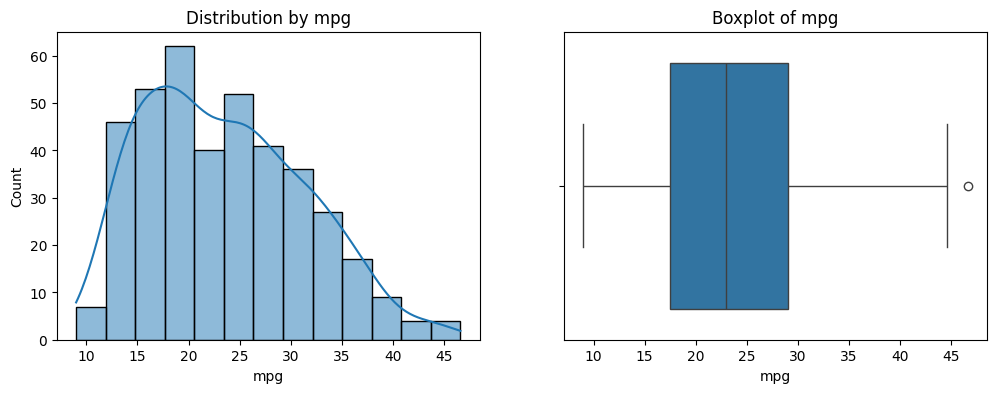

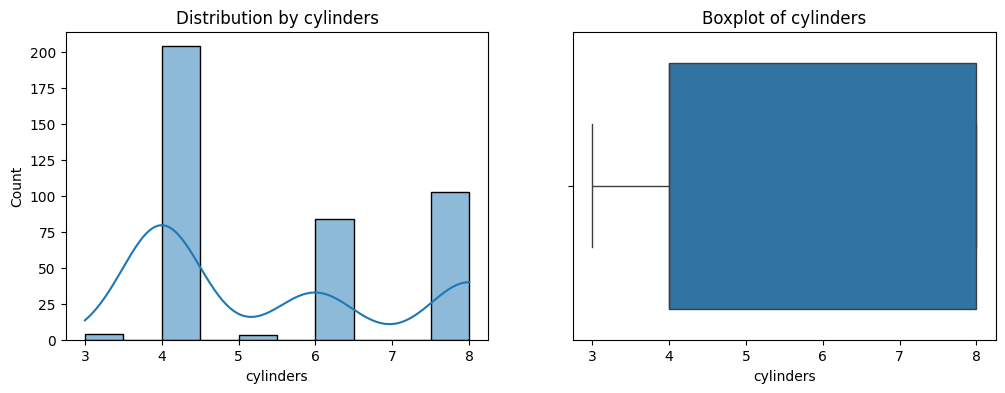

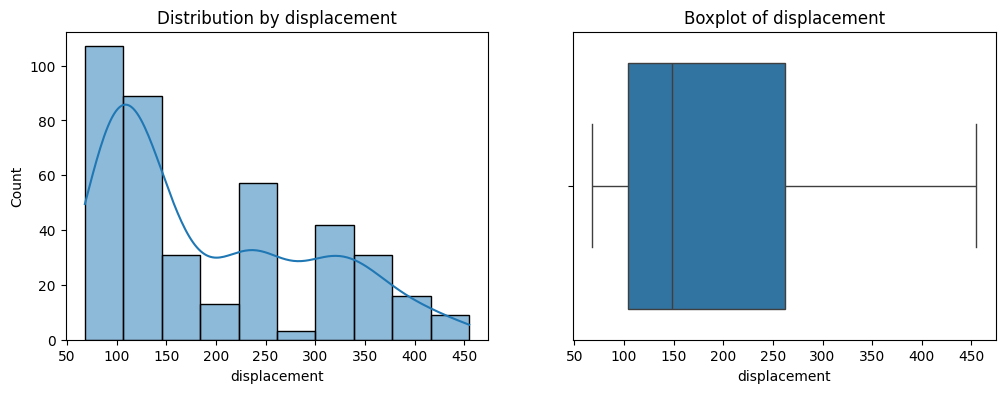

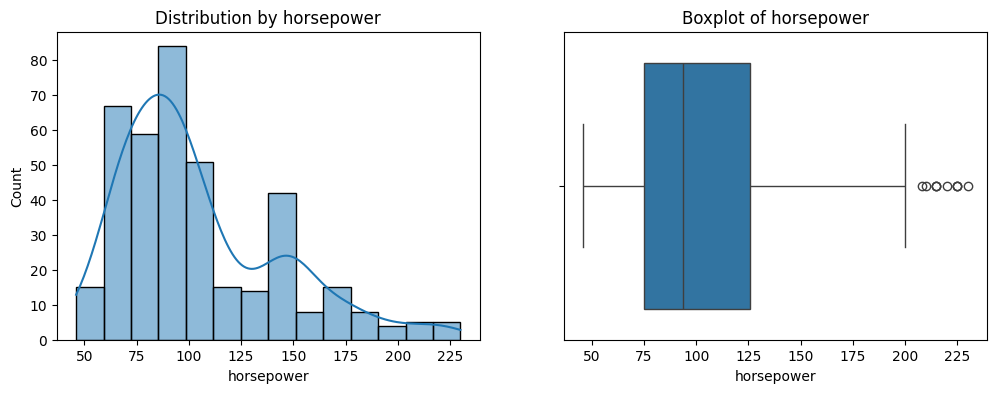

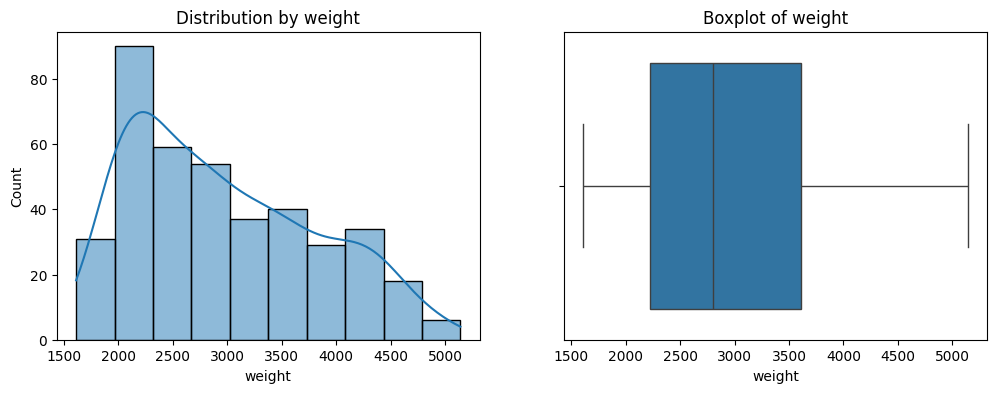

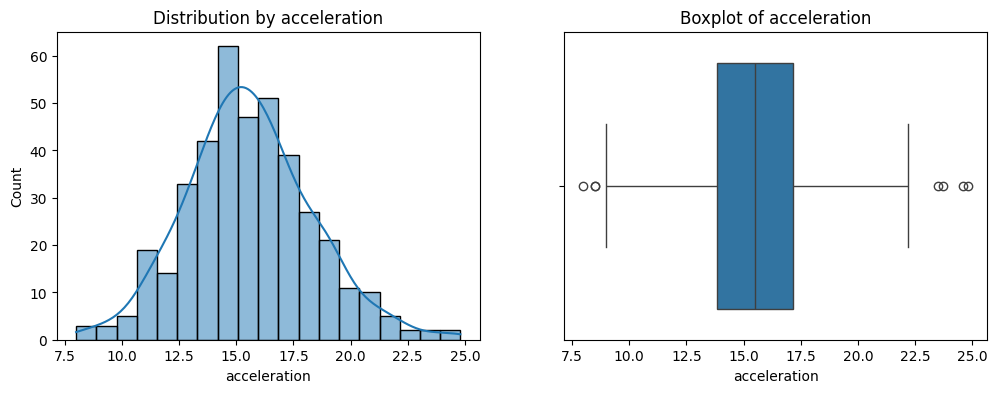

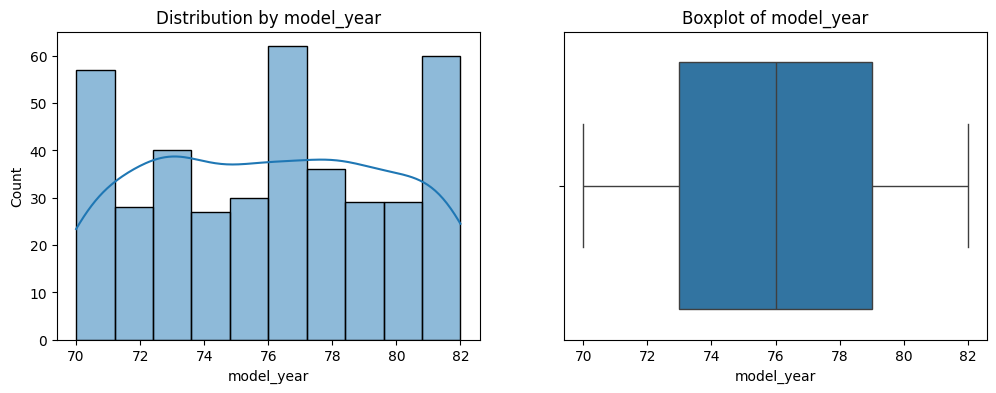

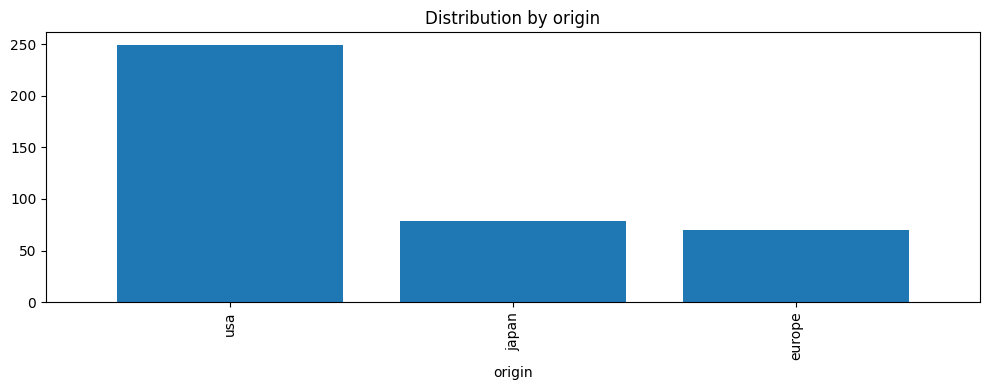

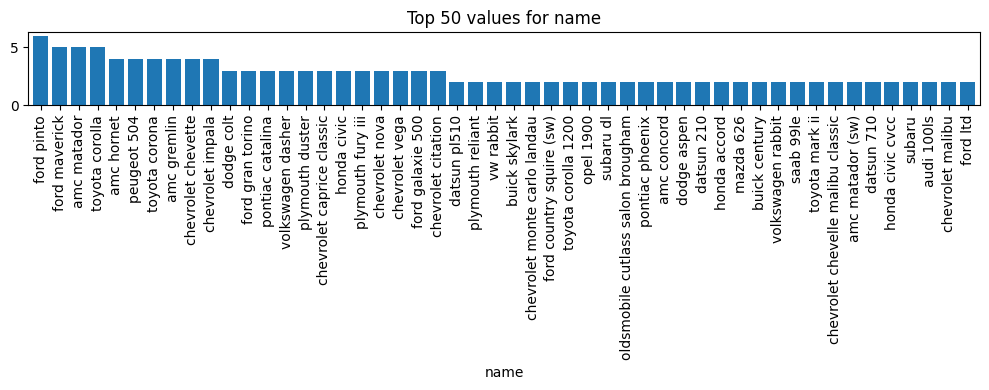

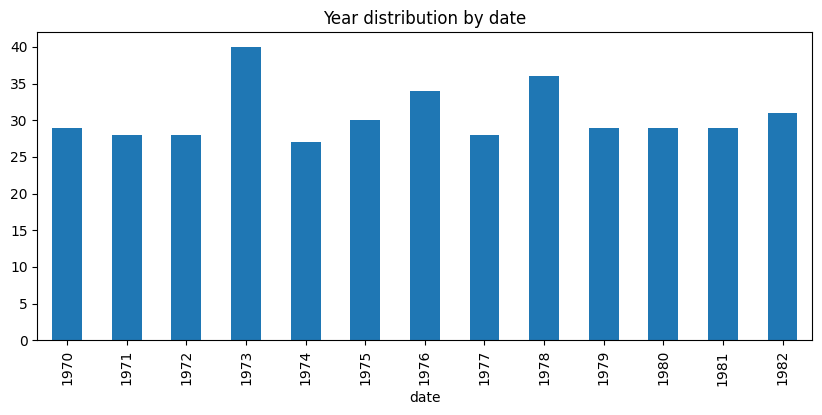

In [215]:
def explorar_dataframe(df):
    for columna in df.columns:
        if df[columna].dtype in ['int64', 'float64']:
            figura, grafic = plt.subplots(1, 2, figsize=(12, 4))
            sns.histplot(df[columna], kde=True, ax=grafic[0])
            grafic[0].set_title(f'Distribution by {columna}')

            sns.boxplot(x=df[columna], ax=grafic[1])
            grafic[1].set_title(f'Boxplot of {columna}')

            plt.show()

        elif df[columna].dtype == 'object' or str(df[columna].dtype) == 'category':
            plt.figure(figsize=(10, 4))
            valors = df[columna].value_counts()
            if len(valors) > 20:
              valors = valors.head(50)
              plt.title(f'Top 50 values for {columna}')
            else:
              plt.title(f'Distribution by {columna}')
            valors.plot(kind='bar', width=0.8)
            plt.tight_layout()
            plt.show()

        elif 'datetime64' in str(df[columna].dtype):
            plt.figure(figsize=(10, 4))
            df[columna].dt.year.value_counts().sort_index().plot(kind='bar')
            plt.title(f'Year distribution by {columna}')
            plt.show()

        else:
            print(f'The column {columna} has an unsupported type: {df[columna].dtype}')

explorar_dataframe(df_mpg)

### Conclusions de l’exploració visual: insights preliminars i valor per al negoci

L’exploració visual automatitzada ha permès obtenir una primera lectura clara i estructurada del dataset, identificant patrons generals i possibles punts d’atenció sense necessitat d’intervenció manual. Aquest tipus d’anàlisi és especialment rellevant en entorns on la rapidesa en la comprensió de les dades és crítica per accelerar la presa de decisions.

A partir dels gràfics generats, es poden extreure conclusions preliminars sobre la distribució de les variables, la presència de valors atípics, la naturalesa de les variables categòriques i la coherència temporal de les dades. Aquest coneixement inicial és essencial per orientar les següents fases del projecte, com ara la neteja, la transformació o la selecció de models analítics.

Des d’una perspectiva de negoci, aquesta aproximació sistemàtica facilita:
- Detectar ràpidament variables amb comportaments inesperats que poden impactar en models predictius o informes executius.
- Identificar oportunitats d’enriquiment de dades o de redefinició d’indicadors.
- Millorar la comunicació entre equips tècnics i no tècnics mitjançant visualitzacions consistents i fàcilment interpretables.
- Reduir temps i costos en la fase inicial d’anàlisi, especialment en projectes amb datasets extensos o heterogenis.

> **Nota:** En aquest exercici, els títols dels gràfics s’han generat en anglès per mantenir la coherència amb els noms de les columnes dels datasets d’exemple de *seaborn* (com *mpg*, *titanic* o *iris*), que utilitzen nomenclatura anglesa de manera nativa. Aquesta decisió garanteix una millor integració i una experiència més homogènia en contextos internacionals o amb fonts de dades diverses.


---
---

## Exercici 2: Optimització de rutes (problema aplicat)

**🌍 Context:**

L'empresa no disposa d'un control fiable del quilometratge dels desplaçaments dels seus treballadors. Abans d'implementar un sistema avançat, es vol fer una prova pilot amb treballadors ubicats a Espanya.

Per a aquesta prova:

- Es treballa amb una matriu de distàncies entre ciutats.

- Es vol una solució simple, raonable i explicable.

- No es busca la ruta òptima, sinó una aproximació coherent.

Carrega l'arxiu matriu_distancies.xlsx a pandas de manera que les files i columnes siguin les ciutats i s'eliminin "Las Palmas de Gran Canaria" i "Palma".

Desenvolupa una funció que:

- Rebi: una ciutat d'origen i una ciutat de destinació.
- Retorni: l'ordre de les ciutats visitades (ruta) i la distància total recorreguda.

La ruta s'ha de construir seguint una estratègia senzilla: anar sempre a la ciutat no visitada més propera fins a arribar a la destinació.

---
---

### Prova pilot de control de quilometratge  

L’empresa vol millorar el control del quilometratge dels desplaçaments dels seus treballadors.  
Abans d’implementar un sistema avançat (GPS, telemetria o aplicacions mòbils), es realitza una **prova pilot** utilitzant una matriu de distàncies entre ciutats d’Espanya.

Aquesta prova té tres requisits clau:

- **Simplicitat:** la solució ha de ser fàcil d’entendre i explicar.  
- **Coherència:** no cal trobar la ruta òptima, però sí una aproximació raonable.  
- **Reproductibilitat:** el procés ha de ser determinista i aplicable a qualsevol parell de ciutats.

Per això s’utilitza una estratègia **greedy**:  
> En cada pas, el sistema avança cap a la ciutat no visitada més propera fins arribar al destí.

Aquesta aproximació permet obtenir rutes **coherents i explicables**, útils per validar el model de distàncies i detectar possibles anomalies en el quilometratge declarat.


In [216]:
from google.colab import files
uploaded = files.upload()

Saving matriu_distancies.xlsx to matriu_distancies.xlsx


In [217]:
df_matriu = pd.read_excel(list(uploaded.keys())[0], index_col=0)
df_matriu

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Palma,Las Palmas de Gran Canaria,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,206.0,2175.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,260.0,1874.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,791.0,1355.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,377.0,2001.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,695.0,1406.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,372.0,1723.0,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Palma,206.0,260.0,791.0,377.0,695.0,372.0,NaN,2093.0,621.0,303.0,671.0,664.0,1000.0,820.0,204.0
Las Palmas de Gran Canaria,2175.0,1874.0,1355.0,2001.0,1406.0,1723.0,2093.0,NaN,2022.0,1792.0,1470.0,1790.0,1682.0,1925.0,2168.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,621.0,2022.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,303.0,1792.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0


In [218]:
ciutats_eliminar = ['Las Palmas de Gran Canaria', 'Palma']
df_matriu = df_matriu.drop(index=ciutats_eliminar, columns=ciutats_eliminar, errors='ignore')
df_matriu

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0
Córdoba,711.0,421.0,121.0,535.0,133.0,320.0,618.0,379.0,NaN,419.0,589.0,634.0,704.0
Valladolid,576.0,441.0,486.0,320.0,549.0,510.0,232.0,515.0,419.0,NaN,337.0,224.0,570.0


In [219]:
def ruta_ciutat_mes_propera(df, origen, desti):
    if origen not in df.index:
        raise ValueError(f"La ciutat d'origen {origen} no existeix al dataframe.")
    if desti not in df.index:
        raise ValueError(f'La ciutat de destinació {desti} no existeix al dataframe.')
    if origen == desti:
        return f"La ciutat d'origen i de destinació són la mateixa."

    ciutats_visitades = [origen]
    ciutat_actual = origen
    distancia_total = 0

    while ciutat_actual != desti:
        distancies = df.loc[ciutat_actual]

        ciutats_candidates = distancies.drop(labels=ciutats_visitades)

        ciutat_propera = ciutats_candidates.idxmin()
        distancia = ciutats_candidates.min()

        ciutats_visitades.append(ciutat_propera)
        distancia_total += distancia
        ciutat_actual = ciutat_propera

    ruta = ' → '.join(ciutats_visitades)

    resultat_final = (
        f'Ruta recomanada entre {origen} i {desti}:\n\n'
        f'{ruta}\n\n'
        f'Distància total estimada: {distancia_total:.1f} km')

    return Markdown(resultat_final)

ruta_ciutat_mes_propera(df_matriu, 'Barcelona', 'Gijón')

Ruta recomanada entre Barcelona i Gijón:

Barcelona → Hospitalet de Llobregat → Zaragoza → Valencia → Alicante → Murcia → Córdoba → Sevilla → Málaga → Valladolid → Gijón

Distància total estimada: 2069.0 km

### Interpretació del resultat

La ruta generada mostra l’ordre de ciutats visitades seguint l’estratègia de “ciutat més propera i no visitada”.

Aquesta estratègia **no garanteix la ruta globalment més curta**, però sí una aproximació consistent i fàcil d’explicar.

**Què aporta aquesta aproximació?**

- **Transparència:** cada decisió es basa en la distància mínima disponible.  
- **Coherència:** evita salts incoherents o rutes poc naturals.  
- **Utilitat operativa:** permet comparar el quilometratge estimat amb el quilometratge declarat pels treballadors.  
- **Detecció d’anomalies:** diferències grans poden indicar errors, desviacions o rutes no justificades.

**Limitacions conegudes**

- No té en compte trànsit, carreteres, orografia ni preferències reals de conducció.  
- No calcula la ruta òptima real.
- Pot passar per ciutats que no serien necessàries en una ruta real.

Tot i això, és una eina **excel·lent per a una prova pilot**, ja que combina simplicitat, explicabilitat i consistència.
